In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib import pyplot as plt
import copy
from netCDF4 import Dataset, num2date, date2num

from scipy import arange, cos, exp
from scipy.interpolate import RegularGridInterpolator
from numpy import unique
from numpy import where
from sklearn.datasets import make_classification

from sklearn import datasets
from sklearn import metrics
from matplotlib import pyplot
import matplotlib.patches as patches
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from haversine import haversine, Unit
import xarray as xr
import seaborn as sns
from scipy.stats import rankdata
from matplotlib import colors as c
import csv

from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
from matplotlib.colors import from_levels_and_colors
import random
import cmaps
from scipy import signal
from datetime import datetime
from scipy.stats import stats
import xarray as xr

import geopandas as gpd
import pandas as pd
import matplotlib.colors as colors
import scipy
import scipy.stats

from statsmodels.nonparametric.smoothers_lowess import lowess

from scipy import interpolate
from scipy.stats import linregress
from cartopy.util import add_cyclic_point

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.datasets import load_boston
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, make_scorer

from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.datasets import load_boston
import xgboost as xgb
import lightgbm as lgb
import shap
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_squared_log_error,median_absolute_error,r2_score,explained_variance_score


def custom_objective(preds, train_data):
    labels = train_data.get_label()
    residual = (labels - preds).astype("float")
    grad = -2 * residual
    hess = 2 * np.ones_like(labels)
    return grad, hess
def custom_r2_metric(preds, train_data):
    labels = train_data.get_label()
    r2 = r2_score(labels, preds)
    return 'r2', r2, True
# Define the custom quantile loss function for scoring
def quantile_loss(y_true, y_pred, alpha=0.9):
    diff = y_true - y_pred
    return np.mean(np.maximum(alpha * diff, (alpha - 1) * diff))

# Create a custom scorer using make_scorer
quantile_loss_scorer = make_scorer(quantile_loss, greater_is_better=False, alpha=0.9)

In [3]:
from scipy.stats import theilslopes
from statsmodels.nonparametric.smoothers_lowess import lowess

# load land mask

In [4]:

NCData = Dataset(r'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe/land_sea_mask_2023_01_01_1x1.nc')
land_mask = np.squeeze(NCData.variables['var172'][:])
lon_era5= NCData.variables['lon'][:][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
print(NCData.variables['lon'][:][:][:10])
print(NCData.variables['lat'][:][:][:10])
NCData.close()


[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[90. 89. 88. 87. 86. 85. 84. 83. 82. 81.]


# CAL fwi

In [5]:
from concurrent.futures import ProcessPoolExecutor
import xarray as xr
import numpy as np
import pandas as pd


def FFMC(TEMP, RH, WIND, RAIN, FFMCPrev):
    """
    Calculates today's Fine Fuel Moisture Code

    Parameters
    ----------
    TEMP: array
        Temperature of the day at noon (celsius)
    RH: array
        Relative humidity of the day at noon (%)
    WIND: array
        Wind speed of the day at noon  (km/h)c
    RAIN: array
        24-hour accumulated rainfall at noon (mm)
    FFMCPrev: array
        Previous day's FFMC (1)

    Returns
    ----------
    FFMC: array
        FFMC on this day (1)
    """

    # preparing initial value mo
    mo = 147.2 * (101.0 - FFMCPrev) / (59.5 + FFMCPrev)

    # case of RAIN > 0.5: modification of mo in this case
    ind_RG05 = np.where(RAIN > 0.5)
    rf = RAIN[ind_RG05] - 0.5
    mr = mo[ind_RG05] + 42.5 * rf * np.exp(-100.0 / (251.0 - mo[ind_RG05])) * (
            1.0 - np.exp(-6.93 / rf)
    )
    # case of m0 > 150: need to add a single term
    ind_moG150 = np.where(mo[ind_RG05] > 150)
    mr[ind_moG150] += (
            0.0015 * pow(mo[ind_RG05][ind_moG150] - 150.0, 2) * pow(rf[ind_moG150], 0.5)
    )
    # limiting mr to 250
    mr[np.where(mr > 250)] = 250
    # updating mo on these cases:
    mo[ind_RG05] = mr

    # variable that will be output
    m = np.nan * np.ones(mo.shape)

    # Preparing threshold
    ed = (
            0.942 * pow(RH, 0.679)
            + 11.0 * np.exp((RH - 100.0) / 10.0)
            + 0.18 * (21.1 - TEMP) * (1.0 - np.exp(-0.115 * RH))
    )

    # Case mo > ed
    ind_moGed = np.where(mo > ed)
    ko = 0.424 * (1.0 - pow(RH[ind_moGed] / 100.0, 1.7)) + 0.0694 * pow(
        WIND[ind_moGed], 0.5
    ) * (1.0 - pow(RH[ind_moGed] / 100.0, 8))
    kd = ko * 0.581 * np.exp(0.0365 * TEMP[ind_moGed])

    m[ind_moGed] = ed[ind_moGed] + (mo - ed)[ind_moGed] * pow(10.0, -kd)

    # Case mo <= ed, with subcases
    ind_moLed = np.where(mo <= ed)
    tmp = m[ind_moLed]  # numpy cant affect values with cases AND subcases
    ew = (
            0.618 * pow(RH[ind_moLed], 0.753)
            + 10.0 * np.exp((RH[ind_moLed] - 100.0) / 10.0)
            + 0.18 * (21.1 - TEMP[ind_moLed]) * (1.0 - np.exp(-0.115 * RH[ind_moLed]))
    )
    #   Subcase m0 < ew
    ind_moLew = np.where(mo[ind_moLed] < ew)
    k1 = 0.424 * (
            1.0 - pow((100.0 - RH[ind_moLed][ind_moLew]) / 100.0, 1.7)
    ) + 0.0694 * pow(WIND[ind_moLed][ind_moLew], 0.5) * (
                 1.0 - pow((100.0 - RH[ind_moLed][ind_moLew]) / 100.0, 8)
         )
    kw = k1 * 0.581 * np.exp(0.0365 * TEMP[ind_moLed][ind_moLew])
    tmp[ind_moLew] = ew[ind_moLew] - (ew[ind_moLew] - mo[ind_moLed][ind_moLew]) * pow(
        10.0, -kw
    )
    #   Subcase m0 >= ew
    ind_moGew = np.where(mo[ind_moLed] >= ew)
    tmp[ind_moGew] = mo[ind_moLed][ind_moGew]
    m[ind_moLed] = tmp

    return 59.5 * (250.0 - m) / (147.2 + m)


def ISI(WIND, FFMC):
    """
    Calculates today's Initial Spread Index

    Parameters
    ----------
    WIND: array
        Wind speed of the day at noon  (km/h)
    FFMC: array
        Fine Fuel Moisture Code of the day (1)

    Returns
    ----------
    ISI: array
        ISI on this day (1)
    """

    fWIND = np.exp(0.05039 * WIND)

    m = 147.2 * (101.0 - FFMC) / (59.5 + FFMC)
    # handling cases of FFMC > 101 (due to the approximation of a coefficient in FFMC: 101 * 147.2 / 59.5 ~=250 )
    m[np.where(FFMC > 101)] = 0

    fF = 91.9 * np.exp(-0.1386 * m) * (1.0 + pow(m, 5.31) / 49300000.0)

    return 0.208 * fWIND * fF


def DryingFactor(Latitude, Month):
    """
    Calculates the Drying Factor.
    NB: this parameter is called "Day-length adjustment in DC". This name is not used here because of the adjustments on the parameter "Effective day-length" used in DMC.

    Option for the drying factor from cfg.adjust_DryingFactor:
        - 'original': values for the Northern hemisphere applied everywhere (Wagner et al, 1987: https://cfs.nrcan.gc.ca/pubwarehouse/pdfs/19927.pdf)
        - 'NSH': the values for the Southern hemisphere are those for the northern shifted by 6 months (https://github.com/buckinha/pyfwi/blob/master/pyFWI/FWIFunctions.py)
        - 'NSHeq': the same idea is applied, but near the equator, one same value is applied for all months (https://rdrr.io/rforge/cffdrs/src/R/dcCalc.R)

    Parameters
    ----------
    Latitude: array
        Latitude in decimal degrees of the location (degree North)
    Month: int
        numeral month, from 1 to 12
    cfg: class configuration_FWI_CMIP6
        Class used to carry information on which calculations have to be performed, specifically on options for adjustments.

    Returns
    ----------
    DryingFactor: array
        Drying Factor (1)
    """

    if len(np.array(Month).shape) > 0:
        raise Exception(
            "This code has been rewritten so that only the month must be a scalar... dont know what to do if there are multiple values."
        )

    # LfN are the original values from the Canadian Fire Weather Index

    LfN = [-1.6, -1.6, -1.6, 0.9, 3.8, 5.8, 6.4, 5.0, 2.4, 0.4, -1.6, -1.6]
    # LfS are the same values shifted by 6 months
    LfS = [6.4, 5.0, 2.4, 0.4, -1.6, -1.6, -1.6, -1.6, -1.6, 0.9, 3.8, 5.8]
    # Lfeq is the average
    Lfeq = 1.39

    retVal = np.nan * np.ones(Latitude.shape)
    ind_LatG0 = np.where(Latitude > 10)
    retVal[ind_LatG0] = LfN[Month - 1]

    ind_LatG0 = np.where((Latitude > -10) & (Latitude <= 10))
    retVal[ind_LatG0] = Lfeq

    ind_LatL0 = np.where(Latitude <= -10)
    retVal[ind_LatL0] = LfS[Month - 1]

    return retVal


def DC(TEMP, RAIN, DCPrev, LAT, MONTH):
    """
    Calculates today's Drought Code

    Parameters
    ----------
    TEMP: array
        Temperature of the day at noon (celsius)
    RAIN: array
        24-hour accumulated rainfall at noon (mm)
    DCPrev: array
        Previous day's DMC (1)
    LAT: array
        Latitude in decimal degrees of the location (degree North)
    MONTH: int
        numeral month, from 1 to 12
    cfg: class configuration_FWI_CMIP6
        Class used to carry information on which calculations have to be performed, specifically on options for adjustments.

    Returns
    ----------
    DC: array
        DC on this day (1)
    """

    # Updating DCPrev
    # Case Rain > 2.8, with subcases
    ind_RG28 = np.where(RAIN > 2.8)
    rd = 0.83 * RAIN[ind_RG28] - 1.27
    Qo = 800.0 * np.exp(-DCPrev[ind_RG28] / 400.0)
    Qr = Qo + 3.937 * rd
    Dr = 400.0 * np.log(800.0 / Qr)
    #   Sub-case Dr > 0
    tmp = DCPrev[ind_RG28]  # numpy cant affect values with cases AND subcases
    ind_DrG0 = np.where(Dr > 0)
    tmp[ind_DrG0] = Dr[ind_DrG0]
    ind_DrL0 = np.where(Dr <= 0)
    tmp[ind_DrL0] = 0.0
    DCPrev[ind_RG28] = tmp

    Lf = DryingFactor(LAT, MONTH)

    # Preparing V
    V = Lf
    # Case TEMP > -2.8
    ind_TGm28 = np.where(TEMP > -2.8)
    V[ind_TGm28] += 0.36 * (TEMP[ind_TGm28] + 2.8)
    # Case V < 0
    V[np.where(V < 0)] = 0

    return DCPrev + 0.5 * V


def DayLength(Latitude, MONTH):
    """
    Calculates the effective Day Length
    Option for the effective day length cfg.adjust_DayLength:
        - 'original': values adapted for Canadian latitudes, depends on the month (Wagner et al, 1987: https://cfs.nrcan.gc.ca/pubwarehouse/pdfs/19927.pdf)
        - 'bins': depends on 4 bins of latitudes and the month (https://github.com/buckinha/pyfwi/blob/master/pyFWI/FWIFunctions.py)
        - 'continuous': depends continuously on latitude and the day of the year (https://github.com/NCAR/fire-indices & https://www.ncl.ucar.edu/Document/Functions/Crop/daylight_fao56.shtml)


    Parameters
    ----------
    Latitude: array
        Latitude in decimal degrees of the location (degree North)
    numb_day: scalar
        Number of the day in the year
    Month: int
        numeral month, from 1 to 12
    cfg: class configuration_FWI_CMIP6
        Class used to carry information on which calculations have to be performed, specifically on options for adjustments.

    Returns
    ----------
    DayLength: array
        Day Length (h)
    """

    DayLength30N = [6.5, 7.5, 9.0, 12.8, 13.9, 13.9, 12.4, 10.9, 9.4, 8.0, 7.0, 6.0]
    DayLength10N_30N = [7.9, 8.4, 8.9, 9.5, 9.9, 10.2, 10.1, 9.7, 9.1, 8.6, 8.1, 7.8]
    DayLength10S_10N = [9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0]
    DayLength30S_10S = [10.1, 9.6, 9.1, 8.5, 8.1, 7.8, 7.9, 8.3, 8.9, 9.4, 9.9, 10.2]
    DayLength30S = [11.5, 10.5, 9.2, 7.9, 6.8, 6.2, 6.5, 7.4, 8.7, 10.0, 11.2, 11.8]

    # setting day length at different latitudes
    retVal = np.nan * np.ones(Latitude.shape)
    ind_latG30L90 = np.where((30 < Latitude) & (Latitude <= 90))
    retVal[ind_latG30L90] = DayLength30N[MONTH - 1]
    ind_latG10L30 = np.where((10 < Latitude) & (Latitude <= 30))
    retVal[ind_latG10L30] = DayLength10N_30N[MONTH - 1]
    ind_latGm10L10 = np.where((-10 < Latitude) & (Latitude <= 10))
    retVal[ind_latGm10L10] = DayLength10S_10N[MONTH - 1]
    ind_latGm30Lm10 = np.where((-30 < Latitude) & (Latitude <= -10))
    retVal[ind_latGm30Lm10] = DayLength30S_10S[MONTH - 1]
    ind_latGm90Lm30 = np.where((-90 <= Latitude) & (Latitude <= -30))
    retVal[ind_latGm90Lm30] = DayLength30S[MONTH - 1]

    return retVal


def DMC(TEMP, RH, RAIN, DMCPrev, LAT, MONTH):
    """
    Calculates today's Duff Moisture Code

    Parameters
    ----------
    TEMP: array
        Temperature of the day at noon (celsius)
    RH: array
        Relative humidity of the day at noon (%)
    RAIN: array
        24-hour accumulated rainfall at noon (mm)
    DMCPrev: array
        Previous day's DMC (1)
    LAT: array
        Latitude in decimal degrees of the location (degree North)
    NUMB_DAY: scalar
        Number of the day in the year
    MONTH: int
        numeral month, from 1 to 12
    cfg: class configuration_FWI_CMIP6
        Class used to carry information on which calculations have to be performed, specifically on options for adjustments.

    Returns
    ----------
    DMC: array
        DMC on this day (1)
    """

    # Changing DMCPrev
    # case of RAIN > 1.5:
    ind_RG15 = np.where(RAIN > 1.5)
    re = 0.92 * RAIN[ind_RG15] - 1.27
    mo = 20.0 + np.exp(5.6348 - DMCPrev[ind_RG15] / 43.43)
    # Preparing b:
    b = np.nan * np.ones(mo.shape)
    # Case DMCPrev<=33
    ind_DMCPrevL33 = np.where(DMCPrev[ind_RG15] <= 33)
    b[ind_DMCPrevL33] = 100.0 / (0.5 + 0.3 * DMCPrev[ind_RG15][ind_DMCPrevL33])
    # Case 33<DMCPrev<=65
    ind_DMCPrevL65 = np.where((33 < DMCPrev[ind_RG15]) & (DMCPrev[ind_RG15] <= 65))
    b[ind_DMCPrevL65] = 14.0 - 1.3 * np.log(DMCPrev[ind_RG15][ind_DMCPrevL65])
    # Case 65<DMCPrev
    ind_DMCPrevG65 = np.where((65 < DMCPrev[ind_RG15]))
    b[ind_DMCPrevG65] = 6.2 * np.log(DMCPrev[ind_RG15][ind_DMCPrevG65]) - 17.2

    # finishing case of Rain > 1.5, with subcases
    mr = mo + 1000.0 * re / (48.77 + b * re)
    pr = 244.72 - 43.43 * np.log(mr - 20.0)
    #   Subcase of pr > 0
    tmp = DMCPrev[ind_RG15]  # numpy cant affect values with cases AND subcases
    ind_prG0 = np.where(pr > 0)
    tmp[ind_prG0] = pr[ind_prG0]
    ind_prL0 = np.where(pr <= 0)
    tmp[ind_prL0] = 0
    DMCPrev[ind_RG15] = tmp

    # Preparing k
    k = np.zeros(TEMP.shape)  # set to 0 for all except where TEMP > -1.1
    ind_TEMPG11 = np.where(TEMP > -1.1)
    d1 = DayLength(LAT, MONTH)

    k[ind_TEMPG11] = (
            1.894
            * (TEMP[ind_TEMPG11] + 1.1)
            * (100.0 - RH[ind_TEMPG11])
            * d1[ind_TEMPG11]
            * 0.000001
    )

    return DMCPrev + 100.0 * k


def BUI(DMC, DC):
    """
    Calculates today's Buildup Index

    Parameters
    ----------
    DMC: array
        Duff Moisture Code of the day (1)
    DC: array
        Drought Code of the day (1)

    Returns
    ----------
    BUI: array
        BUI on this day (1)
    """

    # Preparing U
    U = np.nan * np.ones(DMC.shape)

    # Case DMC <= 0.4 * DC, with subcases
    ind_dmcL04dc = np.where(DMC <= 0.4 * DC)
    tmp = U[ind_dmcL04dc]
    # handling the cases of DMC and DC being 0
    ind_dmc0dc0 = np.where(
        np.isclose(DMC[ind_dmcL04dc], 0) & np.isclose(DC[ind_dmcL04dc], 0)
    )
    tmp[ind_dmc0dc0] = 0
    ind_dmcN0dcN0 = np.where(
        ~np.isclose(DMC[ind_dmcL04dc], 0) | ~np.isclose(DC[ind_dmcL04dc], 0)
    )
    tmp[ind_dmcN0dcN0] = (
            0.8
            * DMC[ind_dmcL04dc][ind_dmcN0dcN0]
            * DC[ind_dmcL04dc][ind_dmcN0dcN0]
            / (DMC[ind_dmcL04dc][ind_dmcN0dcN0] + 0.4 * DC[ind_dmcL04dc][ind_dmcN0dcN0])
    )
    U[ind_dmcL04dc] = tmp

    # Case DMC > 0.4 * DC, with subcases
    ind_dmcG04dc = np.where(DMC > 0.4 * DC)
    tmp = U[ind_dmcG04dc]
    # handling the cases of DMC and DC being 0
    ind_dmc0dc0 = np.where(
        np.isclose(DMC[ind_dmcG04dc], 0) & np.isclose(DC[ind_dmcG04dc], 0)
    )
    tmp[ind_dmc0dc0] = 0
    ind_dmcN0dcN0 = np.where(
        ~np.isclose(DMC[ind_dmcG04dc], 0) | ~np.isclose(DC[ind_dmcG04dc], 0)
    )
    tmp[ind_dmcN0dcN0] = DMC[ind_dmcG04dc][ind_dmcN0dcN0] - (
            1.0
            - 0.8
            * DC[ind_dmcG04dc][ind_dmcN0dcN0]
            / (DMC[ind_dmcG04dc][ind_dmcN0dcN0] + 0.4 * DC[ind_dmcG04dc][ind_dmcN0dcN0])
    ) * (0.92 + pow(0.0114 * DMC[ind_dmcG04dc][ind_dmcN0dcN0], 1.7))
    U[ind_dmcG04dc] = tmp

    # Taking max of U and 0
    U[np.where(U <= 0)] = 0
    return U


def FWI(ISI, BUI):
    """
    Calculates today's Fire Weather Index

    Parameters
    ----------
    ISI: array
        ISI on this day (1)
    BUI: array
        BUI on this day (1)

    Returns
    ----------
    FWI: array
        FWI on this day (1)
    """

    # Preparing fD
    fD = np.nan * np.ones(BUI.shape)

    # Case BUI <= 80
    ind_buiL80 = np.where(BUI <= 80)
    fD[ind_buiL80] = 0.626 * pow(BUI[ind_buiL80], 0.809) + 2.0
    ind_buiG80 = np.where(BUI > 80)
    fD[ind_buiG80] = 1000.0 / (25.0 + 108.64 * np.exp(-0.023 * BUI[ind_buiG80]))

    B = 0.1 * ISI * fD

    # Preparing S (just complying to notations of the original script)
    S = np.copy(B)

    # Case of B > 1
    ind_BG1 = np.where(B > 1)
    S[ind_BG1] = np.exp(2.72 * pow(0.434 * np.log(B[ind_BG1]), 0.647))

    # Simply making sure that they are no negative values
    S[np.where(S < 0)] = 0
    return S


In [ ]:

for i_year in range( 1950,2026):
    print(i_year)
    # 动态构建文件路径
    temp_file = f'/p/projects/ou/rd1/cextremes/data/ERA5/T2m_hourly/ERA5_'+str(i_year)+'_T2m_1.x1._1h_daymax.nc'
    # temp_file = f'/p/projects/ou/rd1/cextremes/data/ERA5/T2m_ERAland/ERAland_'+str(i_year)+'_T2m_1.x1._1h_daymax.nc'
    rh_file = f'/p/projects/ou/rd1/cextremes/data/ERA5/relative_humidity/ERA5_'+str(i_year)+'_RH_1.x1._1h_daymin.nc'
    wind_file = f'/p/projects/ou/rd1/cextremes/data/ERA5/WIND_hourly/ERA5_'+str(i_year)+'_wind10_1.x1._6h_daymean.nc'
    rain_file = f'/p/projects/ou/rd1/cextremes/data/ERA5/precip/ERA5_tot_precip_1h_1.x1._'+str(i_year)+'_daymean.nc'


    # NCData = Dataset(r'/p/projects/ou/rd1/cextremes/data/ERA5/T2m_hourly/ERA5_1950_T2m_1.x1._1h_daymax.nc') #current shape = (365, 180,360)
    # t2m = np.squeeze(NCData.variables['var167'][:])#K

    # NCData = Dataset(r'/p/projects/ou/rd1/cextremes/data/ERA5/relative_humidity/ERA5_1950_RH_1.x1._1h_daymin.nc') #current shape = (365, 180,360)
    # rh = np.squeeze(NCData.variables['rh'][:]) #%


    # NCData = Dataset(r'/p/projects/ou/rd1/cextremes/data/ERA5/precip/ERA5_tot_precip_1h_1.x1._1950_daymean.nc') #current shape = (365, 180,360)
    # pr = np.squeeze(NCData.variables['var228'][:])*24*1000 #mm/d

    # NCData = Dataset(r'/p/projects/ou/rd1/cextremes/data/ERA5/WIND_hourly/ERA5_1950_wind10_1.x1._1h_daymean.nc') #current shape = (365, 180,360)
    # wind = np.squeeze(NCData.variables['wind10'][:]) # m/s



    # 读取NetCDF数据
    temp_ds = xr.open_dataset(temp_file)
    rh_ds = xr.open_dataset(rh_file)
    wind_ds = xr.open_dataset(wind_file)
    rain_ds = xr.open_dataset(rain_file)

    start_time = str(i_year)+'-01-01'  # 起始时间，字符串格式
    end_time = str(i_year)+'-12-31'   # 结束时间，字符串格式

    # 提取变量
    TIME = temp_ds['time'].sel(time=slice(start_time, end_time))

    TEMP1 = temp_ds['var167'].sel(time=slice(start_time, end_time))  # unit: K
    TEMP = TEMP1 - 273.15;  # unit C
    del TEMP1

    RH = rh_ds['rh'].sel(time=slice(start_time, end_time))  # unit: %
    RH = np.clip(RH, 0, 100) 

    WIND1 = wind_ds['wind10'].sel(time=slice(start_time, end_time))  # unit: m/s; ignore name, I just forgot to change
    WIND = WIND1 * 3.6  # unit km/h
    del WIND1
    WIND = np.where(WIND < 0, 0, WIND)

    RAIN = rain_ds['var228'].sel(time=slice(start_time, end_time))*24*1000  # unit: mm/d
    RAIN = np.where(RAIN < 0, 0, RAIN)

    LAT = temp_ds['lat'].values

    # 初始化 FFMC, DMC, DC 和 ISI 数组
    FFMCPrev = 86
    DMCPrev = 6
    DCPrev = 15
    FFMCPrev_array = np.full(TEMP.shape, FFMCPrev)
    DMCPrev_array = np.full(TEMP.shape, DMCPrev)
    DCPrev_array = np.full(TEMP.shape, DCPrev)

    FFMC_array = np.empty(TEMP.shape).astype(np.float32)
    ISI_array = np.empty(TEMP.shape).astype(np.float32)
    DMC_array = np.empty(TEMP.shape).astype(np.float32)
    DC_array = np.empty(TEMP.shape).astype(np.float32)
    BUI_array = np.empty(TEMP.shape).astype(np.float32)
    FWI_array = np.empty(TEMP.shape).astype(np.float32)

    # 计算 FFMC, ISI, DMC, DC 和 BUI

    time_series = temp_ds['time']  # 假设时间维度命名为 'time'
    # 确保时间被正确识别为 cftime 对象
    pd_time_series = time_series.to_index()  # 转换为 Pandas DatetimeIndex，如果可能的话
    months = pd_time_series.month
    # months = pd.to_datetime(TIME).month  % if some model have no 29 in Feb. it will has problem.

    previous_dmc = np.array(DMCPrev_array[0, :, :])  # 假设0是初始时间点
    previous_FFMC = np.array(FFMCPrev_array[0, :, :])
    previous_DC = np.array(DCPrev_array[0, :, :])

    for idx, month in np.ndenumerate(months):
        print(idx)
        # 获取每个格点的时间序列数据
        temp_series = np.array(TEMP[idx[0], :, :])
        rain_series = np.array(RAIN[idx[0], :, :])
        rh_series = np.array(RH[idx[0], :, :])
        wind_series = np.array(WIND[idx[0], :, :])

        lat_expanded = np.broadcast_to(LAT[:, np.newaxis], temp_series.shape)

        DMCPrev_series = np.copy(previous_dmc)
        FFMCPrev_series = np.copy(previous_FFMC)
        DCPrev_series = np.copy(previous_DC)

        FFMC_array[idx[0], :, :] = FFMC(temp_series, rh_series, wind_series, rain_series, FFMCPrev_series)
        ISI_array[idx[0], :, :] = ISI(wind_series, FFMC_array[idx[0], :, :])
        DMC_array[idx[0], :, :] = DMC(temp_series, rh_series, rain_series, DMCPrev_series, lat_expanded, month)
        DC_array[idx[0], :, :] = DC(temp_series, rain_series, DCPrev_series, lat_expanded, month)
        BUI_array[idx[0], :, :] = BUI(DMC_array[idx[0], :, :], DC_array[idx[0], :, :])
        FWI_array[idx[0], :, :] = FWI(ISI_array[idx[0], :, :], BUI_array[idx[0], :, :])

        # 更新previous_dmc为当前计算的DMC，用于下一个时间点的计算
        previous_dmc = np.copy(DMC_array[idx[0], :, :])
        previous_FFMC = np.copy(FFMC_array[idx[0], :, :])
        previous_DC = np.copy(DC_array[idx[0], :, :])

    # 将计算得到的 FWI 数组转换为 DataArray，并保留原始数据集的坐标
    isi_da = xr.DataArray(ISI_array, coords=TEMP.coords, dims=TEMP.dims)
    bui_da = xr.DataArray(BUI_array, coords=TEMP.coords, dims=TEMP.dims)
    fwi_da = xr.DataArray(FWI_array, coords=TEMP.coords, dims=TEMP.dims)
    FFMC_da = xr.DataArray(FFMC_array, coords=TEMP.coords, dims=TEMP.dims)
    DC_da = xr.DataArray(DC_array, coords=TEMP.coords, dims=TEMP.dims)
    DMC_da = xr.DataArray(DMC_array, coords=TEMP.coords, dims=TEMP.dims)

    # 创建一个新的 Dataset 并将 FWI DataArray 作为变量添加进去
    isi_ds = xr.Dataset({'ISI': isi_da})
    bui_ds = xr.Dataset({'BUI': bui_da})
    fwi_ds = xr.Dataset({'FWI': fwi_da})
    FFMC_ds = xr.Dataset({'FFMC': FFMC_da})
    DC_ds = xr.Dataset({'DC': DC_da})
    DMC_ds = xr.Dataset({'DMC': DMC_da})

    # 保存到 NetCDF 文件

    output_prefix_FWI = f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(i_year)+'_daily.nc'
    fwi_ds.to_netcdf(output_prefix_FWI)


2024
(0,)
(1,)
(2,)
(3,)
(4,)
(5,)
(6,)
(7,)
(8,)
(9,)
(10,)
(11,)
(12,)
(13,)
(14,)
(15,)
(16,)
(17,)
(18,)
(19,)
(20,)
(21,)
(22,)
(23,)
(24,)
(25,)
(26,)
(27,)
(28,)
(29,)
(30,)
(31,)
(32,)
(33,)
(34,)
(35,)
(36,)
(37,)
(38,)
(39,)
(40,)
(41,)
(42,)
(43,)
(44,)
(45,)
(46,)
(47,)
(48,)
(49,)
(50,)
(51,)
(52,)
(53,)
(54,)
(55,)
(56,)
(57,)
(58,)
(59,)
(60,)
(61,)
(62,)
(63,)
(64,)
(65,)
(66,)
(67,)
(68,)
(69,)
(70,)
(71,)
(72,)
(73,)
(74,)
(75,)
(76,)
(77,)
(78,)
(79,)
(80,)
(81,)
(82,)
(83,)
(84,)
(85,)
(86,)
(87,)
(88,)
(89,)
(90,)
(91,)
(92,)
(93,)
(94,)
(95,)
(96,)
(97,)
(98,)
(99,)
(100,)
(101,)
(102,)
(103,)
(104,)
(105,)
(106,)
(107,)
(108,)
(109,)
(110,)
(111,)
(112,)
(113,)
(114,)
(115,)
(116,)
(117,)
(118,)
(119,)
(120,)
(121,)
(122,)
(123,)
(124,)
(125,)
(126,)
(127,)
(128,)
(129,)
(130,)
(131,)
(132,)
(133,)
(134,)
(135,)
(136,)
(137,)
(138,)
(139,)
(140,)
(141,)
(142,)
(143,)
(144,)
(145,)
(146,)
(147,)
(148,)
(149,)
(150,)
(151,)
(152,)
(153,)
(154,)
(155,)
(156,)
(157,)

# read fwi

In [6]:

NCData = Dataset(r'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe/land_sea_mask_2023_01_01_1x1.nc')
land_mask = np.squeeze(NCData.variables['var172'][:])
lon_era5= NCData.variables['lon'][:][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
print(NCData.variables['lon'][:][:][:10])
print(NCData.variables['lat'][:][:][:10])
NCData.close()


[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[90. 89. 88. 87. 86. 85. 84. 83. 82. 81.]


In [7]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_FWI_cal_1.x1._3daymean.nc') #current shape = (365, 180,360)

FWI = np.squeeze(NCData.variables['FWI'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()

In [8]:
temp = np.nanmean(FWI,axis=0)
temp[land_mask<0.3]=np.nan

In [9]:
lon_min, lon_max = -10, 40
lat_min, lat_max = 35, 46

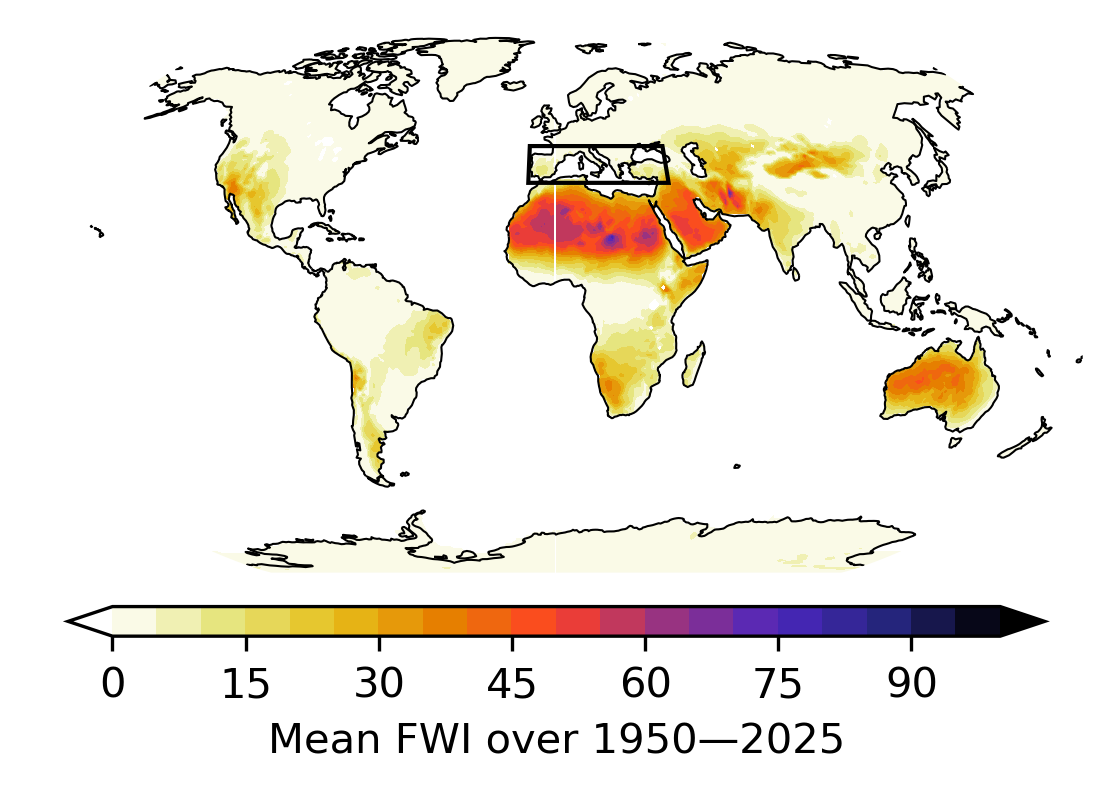

In [10]:
import matplotlib.patches as mpatches
# 绘图
fig, ax = plt.subplots(figsize=(6,3), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(0,105,5)
contour = ax.contourf(
    LON_era5,LAT_era5,temp,
    levels=levels,
    transform=ccrs.PlateCarree(),  
    cmap='CMRmap_r',
    extend='both'
)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.add_patch(rect)

ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=30)
co.set_label(r'Mean FWI over 1950—2025')
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
# ax.set_title('ERA5')
ax.axis('off')
plt.show()

# reginal cluster

## generate labels

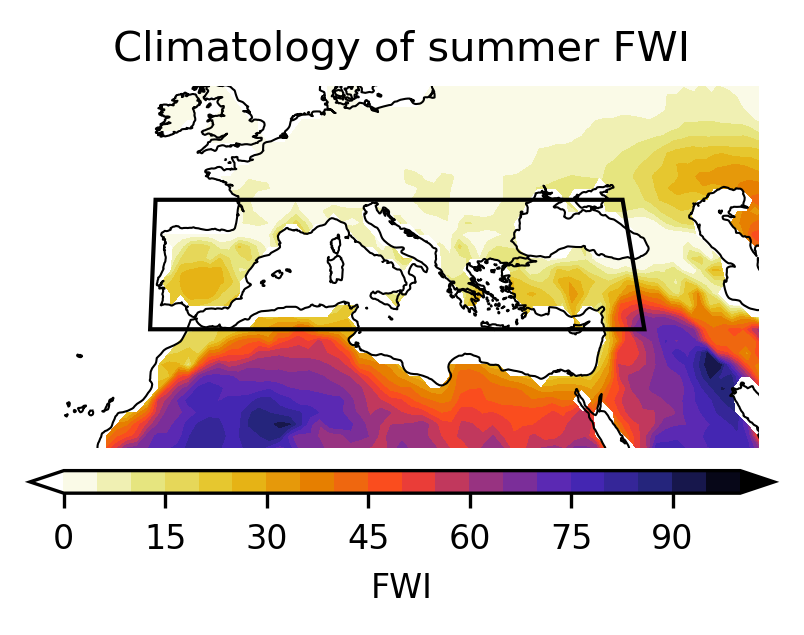

In [11]:
temp_JJA = np.nanmean(FWI[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,range(1979,2026))],axis=0)
temp_JJA[land_mask<0.3]=np.nan
temp_cyclic, lon_cyclic = add_cyclic_point(temp_JJA, coord=LON_era5[0, :])
lon2d, lat2d = np.meshgrid(lon_cyclic, LAT_era5[:, 0])

import matplotlib.patches as mpatches
# 绘图
fig, ax = plt.subplots(figsize=(4,2), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(0,105,5)
contour = ax.contourf(
    lon2d,lat2d,temp_cyclic,
    levels=levels,
    transform=ccrs.PlateCarree(),  
    cmap='CMRmap_r',
    extend='both'
)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.add_patch(rect)

ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, aspect=30)
co.set_label(r'FWI',fontsize=8)
co.ax.tick_params(labelsize=8)
ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())
ax.set_title(r'Climatology of summer FWI',fontsize=10)
ax.axis('off')
plt.show()

In [12]:
temp_JJA_yearly = []
for i_year in range(1979,2026):
    temp_JJA_yearly.append(np.nanmean(FWI[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,i_year)],axis=0))

temp_JJA_yearly = np.array(temp_JJA_yearly)

temp_JJA_yearly_trend = np.zeros((temp_JJA_yearly.shape[1],temp_JJA_yearly.shape[2]))
temp_JJA_yearly_p = np.zeros((temp_JJA_yearly.shape[1],temp_JJA_yearly.shape[2]))

for i_lat in range(temp_JJA_yearly.shape[1]):
    for i_lon in  range(temp_JJA_yearly.shape[2]):
        temp = temp_JJA_yearly[:,i_lat,i_lon]
        slope, intercept, r, p, stderr = linregress( range(1979,2026),temp)
        temp_JJA_yearly_trend[i_lat,i_lon] = slope
        temp_JJA_yearly_p[i_lat,i_lon] = p


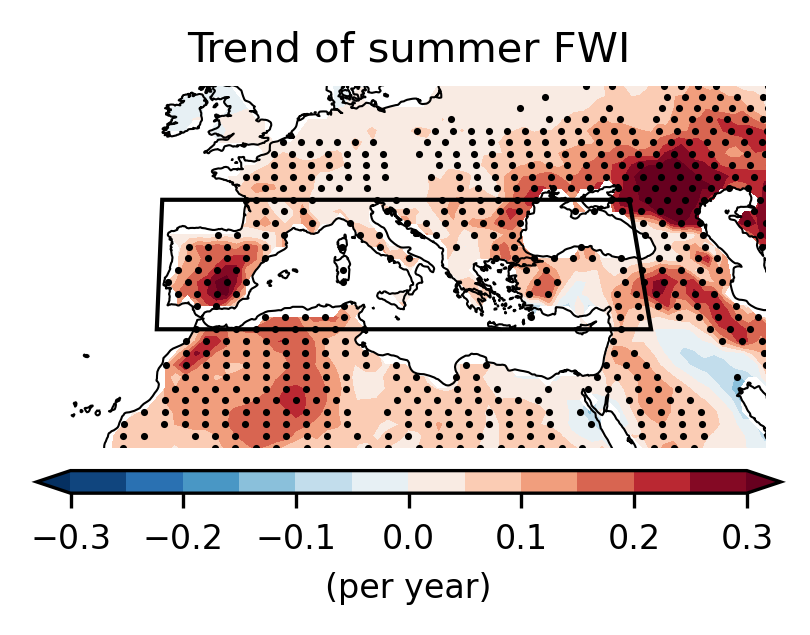

In [13]:


temp_JJA_yearly_trend[land_mask<0.3]=np.nan
temp_JJA_yearly_p[land_mask<0.3]=np.nan
temp_cyclic, lon_cyclic = add_cyclic_point(temp_JJA_yearly_trend, coord=LON_era5[0, :])
lon2d, lat2d = np.meshgrid(lon_cyclic, LAT_era5[:, 0])
import matplotlib.patches as mpatches
# 绘图
fig, ax = plt.subplots(figsize=(4,2), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(-0.3,0.35,0.05)
contour = ax.contourf(
    lon2d, lat2d ,temp_cyclic,
 levels=levels,
    transform=ccrs.PlateCarree(),  
    cmap='RdBu_r',
    extend='both'
)

ax.scatter(
    LON_era5[temp_JJA_yearly_p<0.05][::2],LAT_era5[temp_JJA_yearly_p<0.05][::2],c='k', s=0.5,transform=ccrs.PlateCarree(),)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.add_patch(rect)

ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, aspect=30)
co.set_label(r'(per year)',fontsize=8)
co.ax.tick_params(labelsize=8)
ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())
ax.set_title(r'Trend of summer FWI',fontsize=10)
ax.axis('off')
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Inputs you already have:
#   FWI:        (time, lat, lon)  or (time, y, x)
#   LAT_era5:   (lat, lon)        or (y, x)
#   LON_era5:   (lat, lon)        or (y, x) in 0..360
#   land_mask:  (lat, lon)        or (y, x)  (0..1)
# -----------------------------

# -----------------------------
# 1) Define region (lon in -180..180 convention)
# -----------------------------
lon_min, lon_max = -10, 40
lat_min, lat_max = 35, 46
land_thr = 0.3

# Convert 0..360 lon -> -180..180
LON_era5_180 = ((LON_era5 + 180) % 360) - 180

# Region + land mask (2D boolean mask)
region_mask = (
    (LAT_era5 >= lat_min) & (LAT_era5 <= lat_max) &
    (LON_era5_180 >= lon_min) & (LON_era5_180 <= lon_max) &
    (land_mask >= land_thr)
)
time_mask = (np.in1d(mon_era5_all,[6,7,8]))
# -----------------------------
# 2) Extract spatio-temporal data for clustering
# -----------------------------
# Shape: (time, Npoints_in_region)
FWI_region = FWI[time_mask,:][:, region_mask]

# Optional: remove points that are all-NaN across time
valid_pt = ~np.all(np.isnan(FWI_region), axis=0)
FWI_region = FWI_region[:, valid_pt]

lat_region = LAT_era5[region_mask][valid_pt]
lon_region = LON_era5_180[region_mask][valid_pt]

# Features for KMeans: each grid cell is a sample, with time-series as features
# Shape: (Npoints, time)
X = FWI_region.T

# KMeans cannot handle NaNs: fill remaining NaNs with per-point mean (or 0)
# Here: fill with each point's temporal mean (more conservative than 0)
pt_mean = np.nanmean(X, axis=1, keepdims=True)
X_filled = np.where(np.isnan(X), pt_mean, X)

# Standardize features (important for time-series clustering)
# X_std = StandardScaler().fit_transform(X_filled)



In [15]:
time_mask = (np.in1d(mon_era5_all,[6,7,8]))
year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]

In [16]:



X_std = copy.deepcopy(X_filled )
for i_mon in set(mon_era5_all_JJA):
    mu  = np.nanmean(X_std[:,mon_era5_all_JJA==i_mon] , axis=1, keepdims=True)
    X_std[:,mon_era5_all_JJA==i_mon] = X_std[:,mon_era5_all_JJA==i_mon] -mu

mu  = np.nanmean(X_std, axis=1, keepdims=True)
sig = np.nanstd(X_std, axis=1, keepdims=True)

X_std_grid = (X_std - mu) /sig


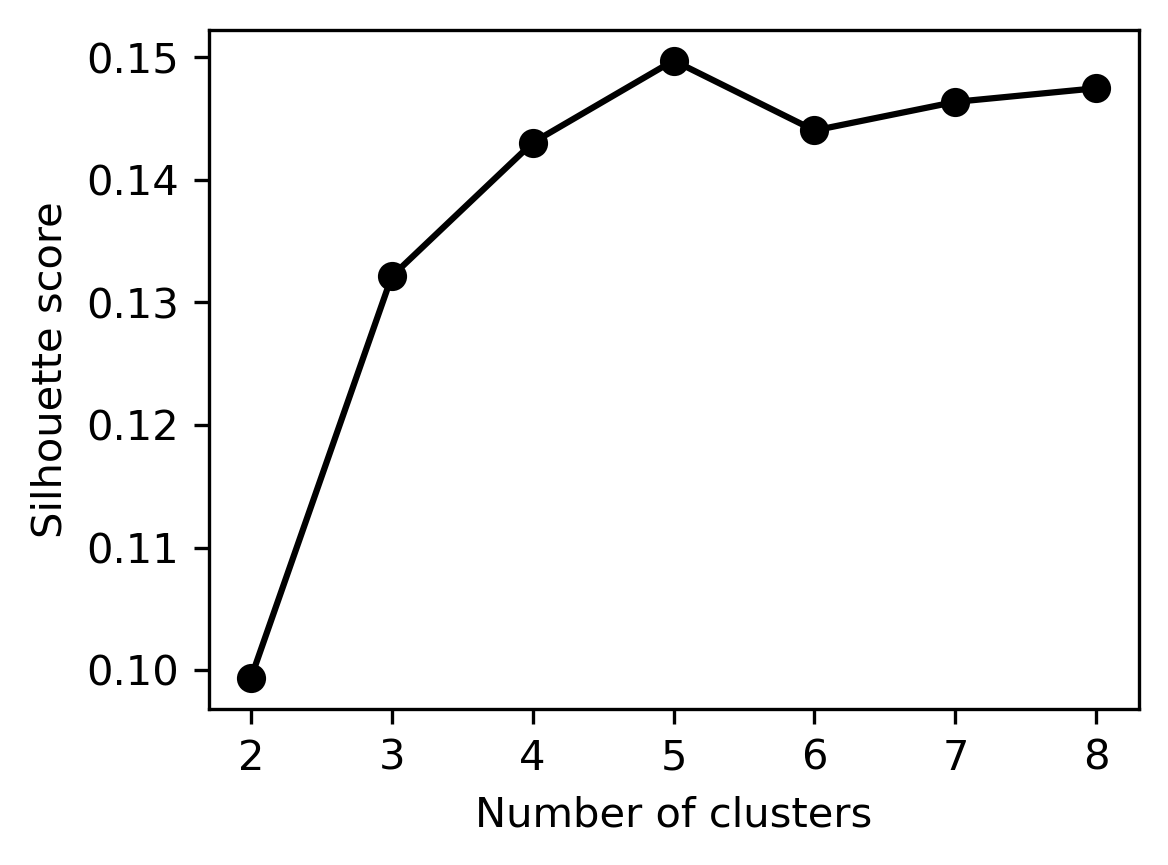

In [17]:
from sklearn.metrics import silhouette_score

sil = []
Ks = range(2, 9)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels_k = km.fit_predict(X_std_grid)
    sil.append(silhouette_score(X_std_grid, labels_k))

plt.figure(figsize=(4,3), dpi=300)
plt.plot(Ks, sil, marker='o',c='k')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
# plt.title("Silhouette analysis")
plt.show()


In [18]:


# -----------------------------
# # 3) KMeans clustering (3 clusters)
# -----------------------------
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=50)
labels = kmeans.fit_predict(X_std_grid)  # (Npoints,)
np.save('Med_JJA_FWI_cluster',labels)

## load labels

In [19]:
labels = np.load('Med_JJA_FWI_cluster.npy',allow_pickle='True')
n_clusters = 3

In [20]:

cluster_colors = {
    0: "#1f77b4",  # blue
    1: "#2ca02c",  # green
    2: "#ff7f0e",  # orange
}

cluster_names = {
    0: "C-Med",  # blue
    1: "E-Med",  # orange
    2: "W-Med",  # green
}

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches


cmap_clusters = ListedColormap(
    [cluster_colors[k] for k in range(n_clusters)]
)

norm_clusters = BoundaryNorm(
    boundaries=np.arange(-0.5, n_clusters + 0.5, 1),
    ncolors=n_clusters
)




Cluster 0: n=141, mean(lat,lon)=(41.82, 18.00)
Cluster 1: n=94, mean(lat,lon)=(39.24, 34.28)
Cluster 2: n=112, mean(lat,lon)=(41.17, -0.77)


The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.


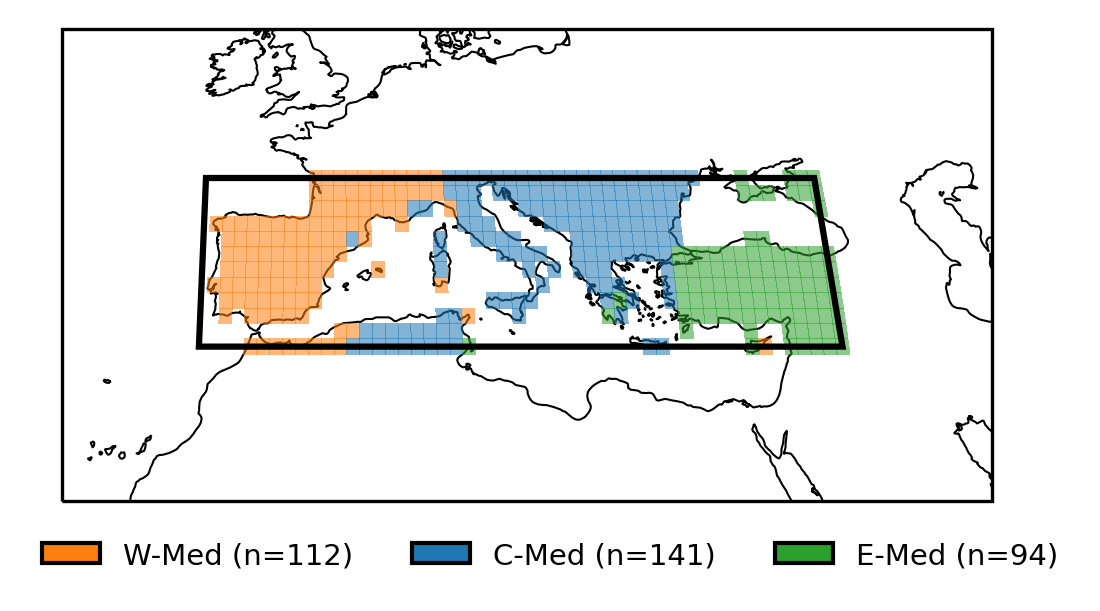

In [21]:

# -----------------------------
# 4) Return lat/lon for each cluster
# -----------------------------
clusters = {}
for k in range(n_clusters):
    clusters[k] = {
        "lat": lat_region[labels == k],
        "lon": lon_region[labels == k],
        "npoints": int(np.sum(labels == k))
    }

# Print summary + approximate "centroid location" (mean lat/lon)
for k in range(n_clusters):
    clat = np.mean(clusters[k]["lat"])
    clon = np.mean(clusters[k]["lon"])
    print(f"Cluster {k}: n={clusters[k]['npoints']}, mean(lat,lon)=({clat:.2f}, {clon:.2f})")

# -----------------------------
# 5) Build a 2D cluster map for plotting (NaN outside region)
# -----------------------------
cluster_map = np.full(LAT_era5.shape, np.nan, dtype=float)

# Put labels back into the region points that survived valid_pt filtering
tmp = np.full(lat_region.shape, np.nan, dtype=float)
tmp[:] = labels
cluster_map[region_mask] = np.nan
cluster_map[region_mask][valid_pt] = tmp

# NOTE: The line above may not assign as expected because boolean indexing makes a copy.
# Use indices to be safe:
idx = np.where(region_mask)
cluster_map[idx] = np.nan
cluster_map[idx[0][valid_pt], idx[1][valid_pt]] = labels

# -----------------------------
# 6) Plot: mean FWI + rectangle + cluster overlay
# -----------------------------
fig, ax = plt.subplots(figsize=(4, 3), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
fig.patch.set_alpha(0)

# levels = np.arange(0, 105, 5)
# contour = ax.contourf(
#     LON_era5_180, LAT_era5, np.nanmean(FWI, axis=0),
#     levels=levels,
#     transform=ccrs.PlateCarree(),
#     cmap='coolwarm',
#     extend='both'
# )

# Rectangle box
rect = mpatches.Rectangle(
    (lon_min, lat_min),
    lon_max - lon_min,
    lat_max - lat_min,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)
ax.add_patch(rect)

# Cluster overlay (only in region)
pm = ax.pcolormesh(
    LON_era5_180, LAT_era5, cluster_map,
    transform=ccrs.PlateCarree(),
    shading='auto',
    alpha=0.55,
    zorder=9,
    cmap = cmap_clusters,
    norm = norm_clusters
)

ax.coastlines(linewidth=0.5)
# co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=30)
# co.set_label('Mean FWI')

ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())
# ax.set_title('ERA5 (3 KMeans clusters)')
# ax.axis('off')


# -----------------------------
# clusters dict is your "return":
# clusters[0]["lat"], clusters[0]["lon"], etc.
# -----------------------------


legend_handles = [
    mpatches.Patch(
        facecolor=cluster_colors[k],
        edgecolor='black',
        label=f"{cluster_names[k]} (n={clusters[k]['npoints']})"
    )
    for k in [2,0,1]
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=False,
    fontsize=7,
    bbox_to_anchor=(-0.05,-0.2),
    ncol=3
)


# FWI regional mean

## write FWI index

In [22]:
def cluster_region_mean_allyear(var_globe):
    land_thr = 0.3

    # Convert 0..360 lon -> -180..180
    LON_era5_180 = ((LON_era5 + 180) % 360) - 180

    region_mask = (
        (LAT_era5 >= lat_min) & (LAT_era5 <= lat_max) &
        (LON_era5_180 >= lon_min) & (LON_era5_180 <= lon_max) &
        (land_mask >= land_thr)
    )

    var_region = var_globe[:, region_mask]


    X = var_region.T


    FWI_region_clusters_allyear = []
    for i_label in range(n_clusters):
        temp = np.nanmean(X[labels==i_label],axis=0)
        temp= np.array([i for i in temp])
        FWI_region_clusters_allyear.append(temp)

    return FWI_region_clusters_allyear



def cluster_regional_mean(var_globe):

    land_thr = 0.3

    # Convert 0..360 lon -> -180..180
    LON_era5_180 = ((LON_era5 + 180) % 360) - 180

    # Region + land mask (2D boolean mask)
    region_mask = (
        (LAT_era5 >= lat_min) & (LAT_era5 <= lat_max) &
        (LON_era5_180 >= lon_min) & (LON_era5_180 <= lon_max) &
        (land_mask >= land_thr)
    )
    time_mask = (np.in1d(mon_era5_all,[6,7,8]))

    var_region = var_globe[time_mask,:][:, region_mask]

    X = var_region.T

    X_std = copy.deepcopy(X )

    var_region_clusters = []
    for i_label in range(n_clusters):
        temp = np.nanmean(X_std [labels==i_label],axis=0)
        var_region_clusters.append(temp)
    return var_region_clusters 

In [72]:
np.save('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/time_year_1950_2025_3d',year_era5_all)
np.save('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/time_mon_1950_2025_3d',mon_era5_all)
np.save('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/time_day_1950_2025_3d',day_era5_all)

In [50]:
FWI_allyear_region_clusters  = cluster_region_mean_allyear(FWI)

for k in range(n_clusters):
    np.save('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/'+cluster_names[k]+'_FWI_1950_2025_3d',FWI_allyear_region_clusters [k])

## regional mean

In [23]:

land_thr = 0.3

# Convert 0..360 lon -> -180..180
LON_era5_180 = ((LON_era5 + 180) % 360) - 180

# Region + land mask (2D boolean mask)
region_mask = (
    (LAT_era5 >= lat_min) & (LAT_era5 <= lat_max) &
    (LON_era5_180 >= lon_min) & (LON_era5_180 <= lon_max) &
    (land_mask >= land_thr)
)
time_mask = (np.in1d(mon_era5_all,[6,7,8]))
# -----------------------------
# 2) Extract spatio-temporal data for clustering
# -----------------------------
# Shape: (time, Npoints_in_region)
FWI_region = FWI[time_mask,:][:, region_mask]

# Optional: remove points that are all-NaN across time
valid_pt = ~np.all(np.isnan(FWI_region), axis=0)
FWI_region = FWI_region[:, valid_pt]

lat_region = LAT_era5[region_mask][valid_pt]
lon_region = LON_era5_180[region_mask][valid_pt]

# Features for KMeans: each grid cell is a sample, with time-series as features
# Shape: (Npoints, time)
X = FWI_region.T

# KMeans cannot handle NaNs: fill remaining NaNs with per-point mean (or 0)
# Here: fill with each point's temporal mean (more conservative than 0)
pt_mean = np.nanmean(X, axis=1, keepdims=True)
X_filled = np.where(np.isnan(X), pt_mean, X)

# Standardize features (important for time-series clustering)
# X_std = StandardScaler().fit_transform(X_filled)

year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]


X_std = copy.deepcopy(X_filled )
# for i_date in set(day_era5_all_JJA):
#     mu  = np.nanmean(X_std[:,day_era5_all_JJA==i_date] , axis=1, keepdims=True)
#     X_std[:,day_era5_all_JJA==i_date] = X_std[:,day_era5_all_JJA==i_date] -mu

#     mu  = np.nanmean(X_std, axis=1, keepdims=True)
#     sig = np.nanstd(X_std, axis=1, keepdims=True)

#     X_std_grid = (X_std - mu) /sig



FWI_region_clusters = []
for i_label in range(n_clusters):
    temp = np.nanmean(X_std [labels==i_label],axis=0)
    FWI_region_clusters.append(temp)


########################################
FWI_ano_region_clusters = []
for i_label in range(n_clusters):
    temp = np.nanmean(X_std_grid [labels==i_label],axis=0)
    for i_mon in set(mon_era5_all_JJA):
        mu  = np.nanmean(temp[mon_era5_all_JJA==i_mon] )
        temp[mon_era5_all_JJA==i_mon] = temp[mon_era5_all_JJA==i_mon] -mu
    for i_year in set(year_era5_all_JJA):
        mu  = np.nanmean(temp[year_era5_all_JJA==i_year])
        temp[year_era5_all_JJA==i_year] = temp[year_era5_all_JJA==i_year] -mu        
    FWI_ano_region_clusters.append(temp)



## annual mean

In [24]:
cluster_sequence = [2,0,1]

W-Med: slope = 0.112 per yr (95% CI [0.072, 0.149])
C-Med: slope = 0.080 per yr (95% CI [0.036, 0.121])
E-Med: slope = 0.079 per yr (95% CI [0.026, 0.124])


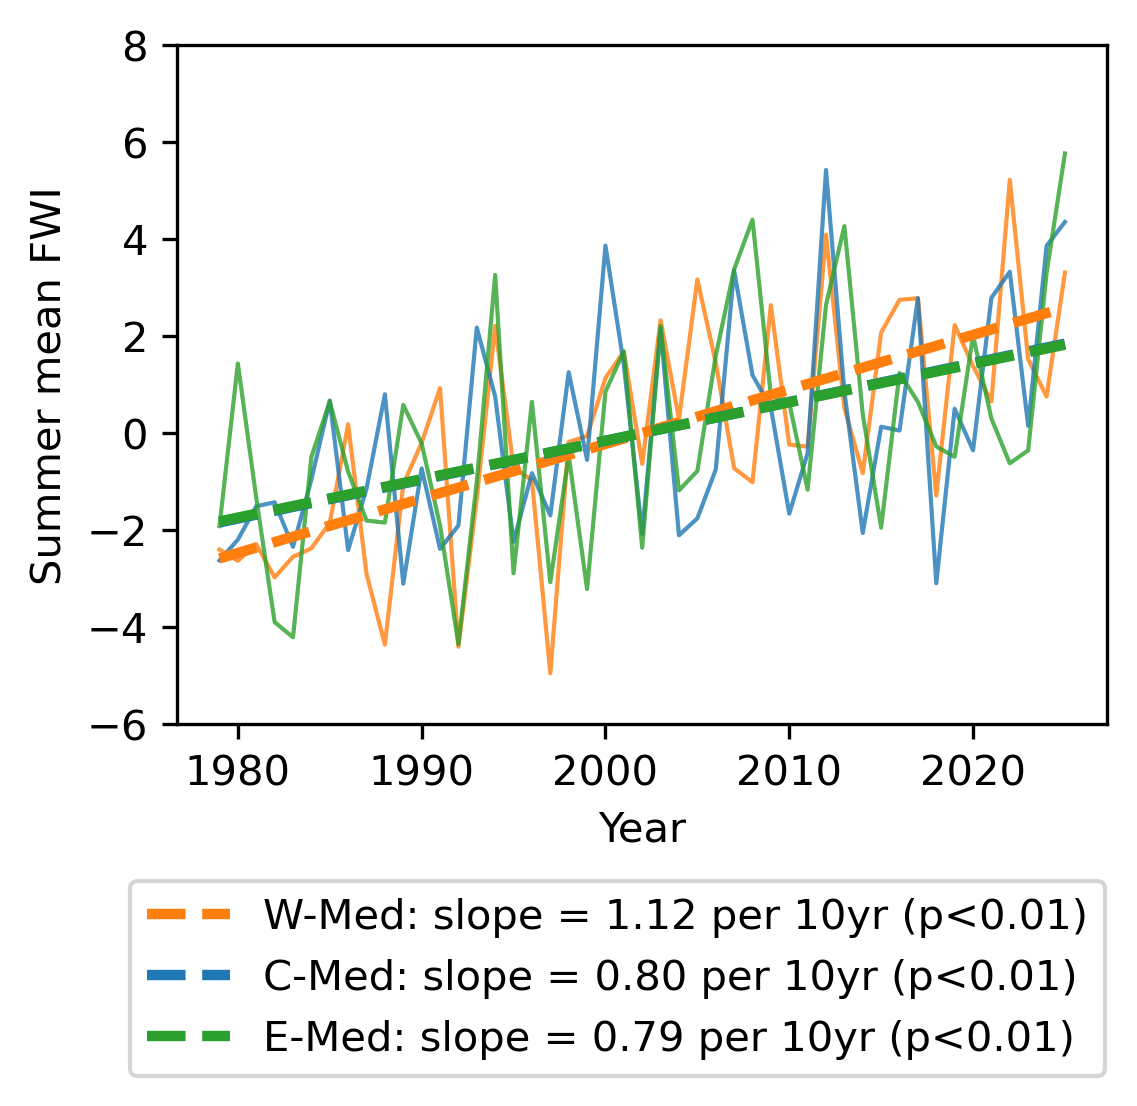

In [25]:
years = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}

for k in cluster_sequence:
    temp = FWI_region_clusters[k]
    temp_yearmean = np.array([
        np.nanmean(temp[year_era5_all_JJA == y]) for y in years
    ])
    temp_yearmean = temp_yearmean - np.nanmean(temp_yearmean)
    annual_means[k] = temp_yearmean 

    ax.plot(
        years,
        temp_yearmean,
        color=cluster_colors[k],
        lw=1.,
        alpha=0.8,
        # label=cluster_names[k]
    )


for k in cluster_sequence:
    y = annual_means[k]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]
    if p<0.01:
            ax.plot(
        years[mask],
        trend,
        color=cluster_colors[k],
        lw=2.5,
        linestyle="--",
        label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10yr (p<0.01)" 
    )
    else:
         
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10yr (p={p:.2f})" 
        )

    print(
        f"{cluster_names[k]}: "
        f"slope = {slope:.3f} per yr "
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )


ax.set_xlabel('Year')
ax.set_ylabel('Summer mean FWI')
plt.ylim(-6,8)
plt.legend(bbox_to_anchor=(1.02,-0.2))
# plt.legend()

## annual extreme

W-Med: slope = 0.041 per yr(95% CI [0.000, 0.050])
C-Med: slope = 0.033 per yr(95% CI [0.000, 0.056])
E-Med: slope = 0.039 per yr(95% CI [0.000, 0.053])


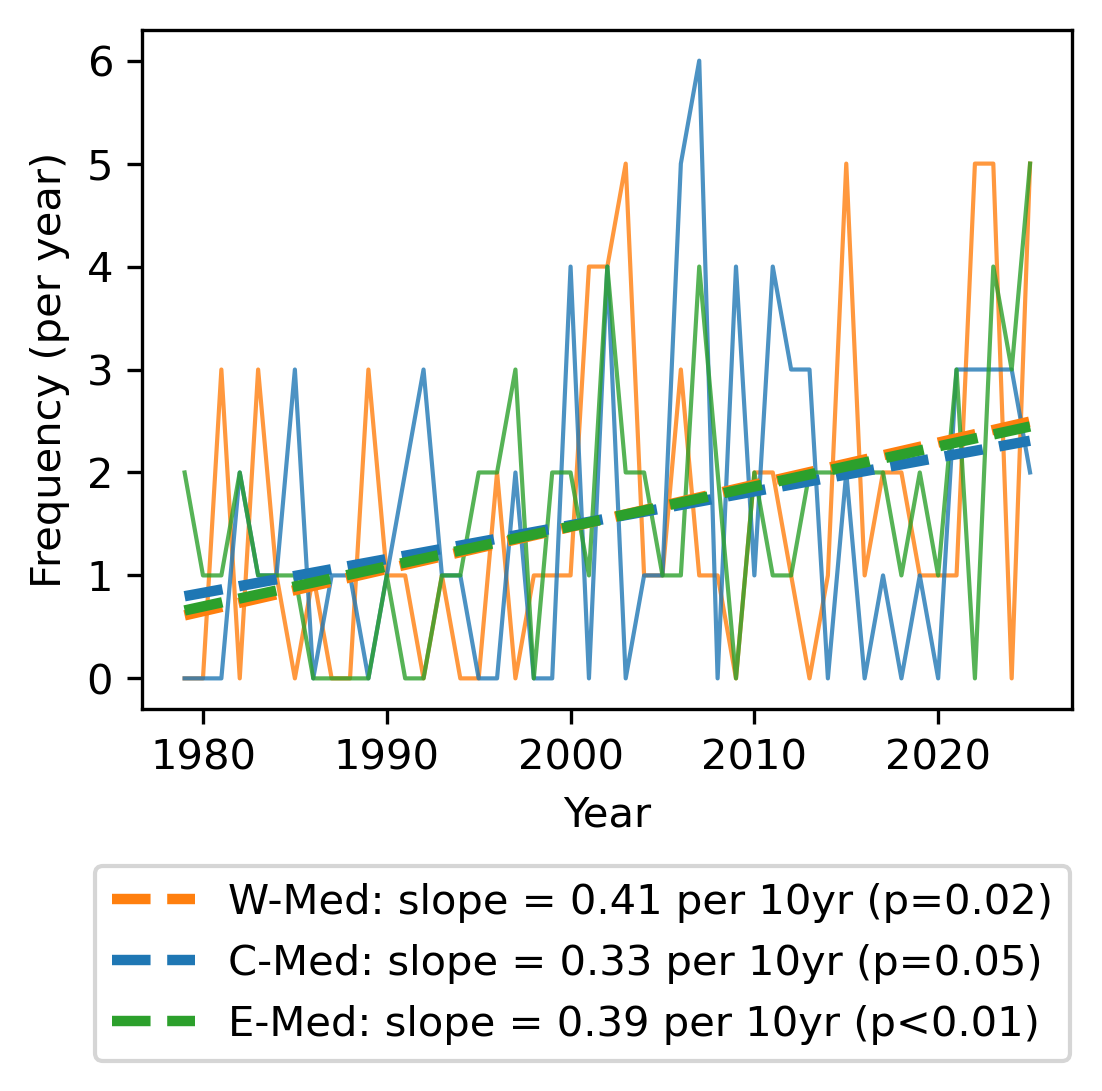

In [82]:
slopeyears = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}

for k in cluster_sequence:
    temp = FWI_ano_region_clusters[k]
    temp_thr = np.nanpercentile(FWI_ano_region_clusters[k][29*31:],95)
    temp_yearmean = np.array([
        len(temp[year_era5_all_JJA == y][temp[year_era5_all_JJA == y]>temp_thr] ) for y in years
    ])
    annual_means[k] = temp_yearmean

    ax.plot(
        years,
        temp_yearmean,
        color=cluster_colors[k],
        lw=1.,
        alpha=0.8,
        # label=cluster_names[k]
    )


for k in cluster_sequence:
    y = annual_means[k]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    
    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]

    
    if p<0.01:
            ax.plot(
        years[mask],
        trend,
        color=cluster_colors[k],
        lw=2.5,
        linestyle="--",
        label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10yr (p<0.01)" 
    )
    else:
         
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10yr (p={p:.2f})" 
        )

    print(
        f"{cluster_names[k]}: "
        f"slope = {slope:.3f} per yr"
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )

# for k in cluster_sequence:
#     y = annual_means[k]
#     mask = ~np.isnan(y)

#     lowess_fit = lowess(
#         y[mask],
#         years[mask],
#         frac=0.2,      # ~15-year smoothing
#         return_sorted=False
#     )

#     ax.plot(
#         years[mask],
#         lowess_fit,
#         color=cluster_colors[k],
#         lw=3,
#         alpha=0.35,
#         label = f"{cluster_names[k]}: " + f"LOESS" 
#     )
ax.set_xlabel('Year')
ax.set_ylabel('Frequency (per year)')
plt.legend(bbox_to_anchor=(1.02,-0.2))

W-Med: slope = 0.042 per yr(95% CI [0.000, 0.057])
C-Med: slope = 0.038 per yr(95% CI [0.000, 0.059])
E-Med: slope = 0.038 per yr(95% CI [0.000, 0.058])


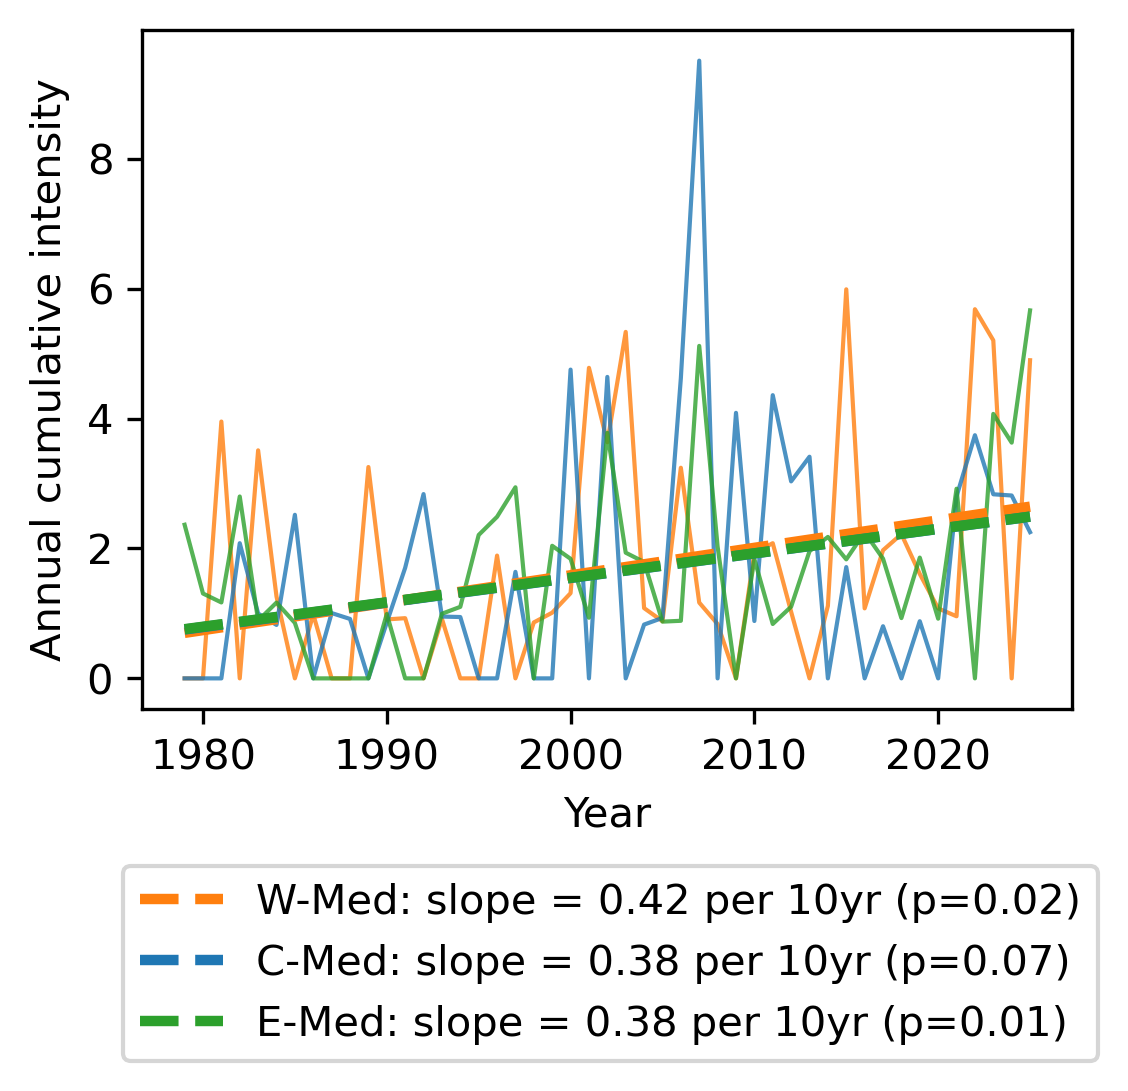

In [80]:
years = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}

for k in cluster_sequence:
    temp = FWI_ano_region_clusters[k]
    temp_thr = np.nanpercentile(FWI_ano_region_clusters[k][29*31:],95)
    temp_yearmean = np.array([
        np.nansum(temp[year_era5_all_JJA == y][temp[year_era5_all_JJA == y]>temp_thr] ) for y in years
    ])
    temp_yearmean[np.isnan(temp_yearmean)]=0
    annual_means[k] = temp_yearmean

    ax.plot(
        years,
        temp_yearmean,
        color=cluster_colors[k],
        lw=1.,
        alpha=0.8,
        # label=cluster_names[k]
    )


for k in cluster_sequence:
    y = annual_means[k]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    


    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]

    ax.plot(
        years[mask],
        trend,
        color=cluster_colors[k],
        lw=2.5,
        linestyle="--",
        label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10yr (p={p:.2f})" 
    )
    
    print(
        f"{cluster_names[k]}: "
        f"slope = {slope:.3f} per yr"
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )

# for k in cluster_sequence:
#     y = annual_means[k]
#     mask = ~np.isnan(y)

#     lowess_fit = lowess(
#         y[mask],
#         years[mask],
#         frac=0.2,      # ~15-year smoothing
#         return_sorted=False
#     )

#     ax.plot(
#         years[mask],
#         lowess_fit,
#         color=cluster_colors[k],
#         lw=3,
#         alpha=0.35,
#         label = f"{cluster_names[k]}: " + f"LOESS" 
#     )
ax.set_xlabel('Year')
ax.set_ylabel('Annual cumulative intensity')
plt.legend(bbox_to_anchor=(1.05,-0.2))

W-Med: slope = 0.013 per yr(95% CI [0.000, 0.014])
C-Med: slope = 0.007 per yr(95% CI [0.000, 0.009])
E-Med: slope = 0.004 per yr(95% CI [-0.004, 0.004])


Mean of empty slice
Mean of empty slice
Mean of empty slice


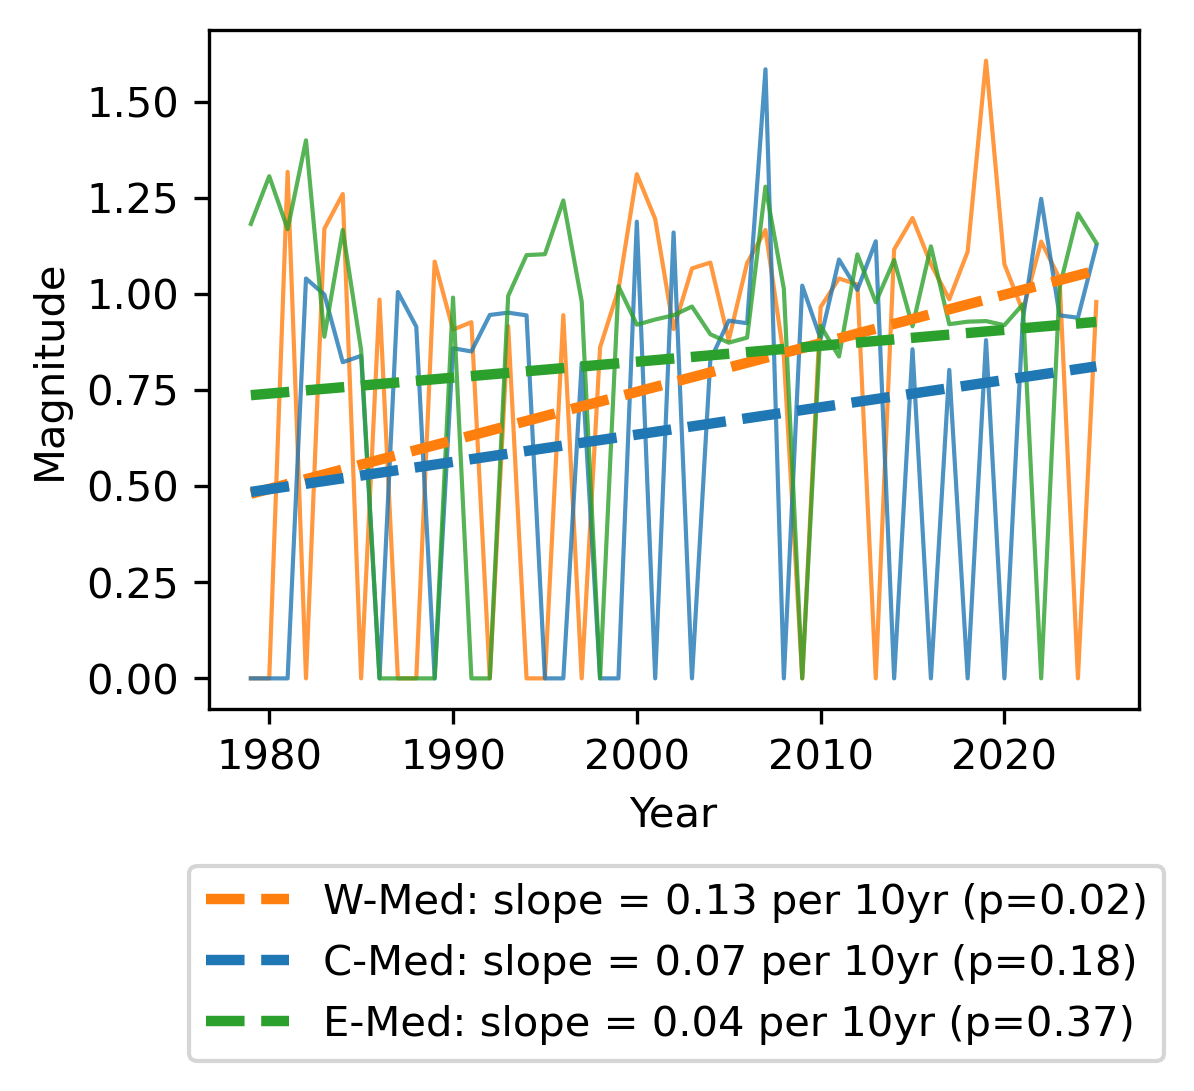

In [81]:
years = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}

for k in cluster_sequence:
    temp = FWI_ano_region_clusters[k]
    temp_thr = np.nanpercentile(FWI_ano_region_clusters[k][29*31:],95)
    temp_yearmean = np.array([
        np.nanmean(temp[year_era5_all_JJA == y][temp[year_era5_all_JJA == y]>temp_thr] ) for y in years
    ])
    temp_yearmean[np.isnan(temp_yearmean)]=0
    annual_means[k] = temp_yearmean

    ax.plot(
        years,
        temp_yearmean,
        color=cluster_colors[k],
        lw=1.,
        alpha=0.8,
        # label=cluster_names[k]
    )


for k in cluster_sequence:
    y = annual_means[k]
    mask = (~np.isnan(y))&(years>=1960)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years

    if p<0.01:
        ax.plot(
        years,
        trend,
        color=cluster_colors[k],
        lw=2.5,
        linestyle="--",
        label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10yr (p<0.01)" 
    )
    else:
        ax.plot(
            years,
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10yr (p={p:.2f})" 
        )

    print(
        f"{cluster_names[k]}: "
        f"slope = {slope:.3f} per yr"
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )

# for k in cluster_sequence:
#     y = annual_means[k]
#     mask = ~np.isnan(y)

#     lowess_fit = lowess(
#         y[mask],
#         years[mask],
#         frac=0.2,      # ~15-year smoothing
#         return_sorted=False
#     )

#     ax.plot(
#         years[mask],
#         lowess_fit,
#         color=cluster_colors[k],
#         lw=3,
#         alpha=0.35,
#         label = f"{cluster_names[k]}: " + f"LOESS" 
#     )
ax.set_xlabel('Year')
ax.set_ylabel('Magnitude')
plt.legend(bbox_to_anchor=(1.05,-0.2))

# Surface variable

In [35]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_swvl1_land_1.x1._3daymean.nc') #current shape = (365, 180,360)

SM = np.squeeze(NCData.variables['var39'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()

In [36]:
SM_allyear_region_clusters  = cluster_region_mean_allyear(SM)

In [ ]:

for k in range(n_clusters):
    np.save('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/'+cluster_names[k]+'_SM_1950_2025_3d',SM_allyear_region_clusters [k])

In [35]:
SM_region_clusters  = cluster_regional_mean(SM)

W-Med: slope = -0.001 m$^-3$/m$^-3$/yr (95% CI [-0.001, -0.000])
C-Med: slope = -0.001 m$^-3$/m$^-3$/yr (95% CI [-0.001, -0.000])
E-Med: slope = -0.000 m$^-3$/m$^-3$/yr (95% CI [-0.001, 0.000])


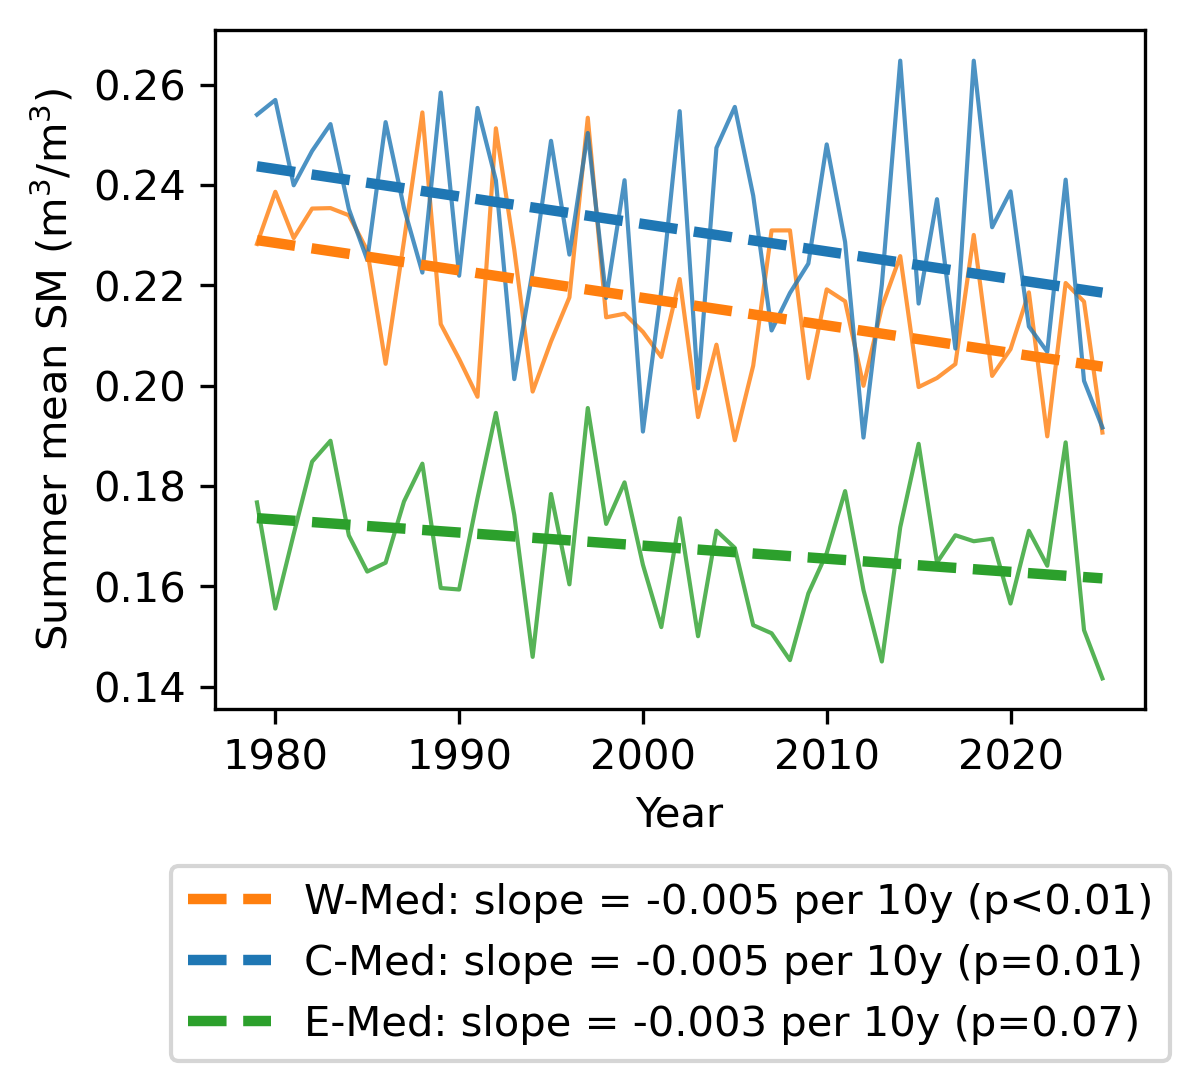

In [36]:




years = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}

for k in cluster_sequence:
    temp = SM_region_clusters[k]
    temp_FWI = FWI_region_clusters[k]

    # temp_yearmean = np.array([
    #     np.nanmean(temp[year_era5_all_JJA == y][temp_FWI[year_era5_all_JJA == y]>temp_FWI_thr] ) for y in years
    # ])
    temp_yearmean = np.array([
        np.nanmean(temp[year_era5_all_JJA == y] ) for y in years
    ])

    temp_yearmean = temp_yearmean 
   
    annual_means[k] = temp_yearmean

    ax.plot(
        years,
        temp_yearmean,
        color=cluster_colors[k],
        lw=1.,
        alpha=0.8,
        # label=cluster_names[k]
    )


for k in cluster_sequence:
    y = annual_means[k]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]

    if p<0.01:
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.3f} per 10y (p<0.01)" 
        )
    else:
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.3f} per 10y (p={p:.2f})" 
        )        

    print(
        f"{cluster_names[k]}: "
        f"slope = {slope:.3f} m$^{-3}$/m$^{-3}$/yr "
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )

# for k in cluster_sequence:
#     y = annual_means[k]
#     mask = ~np.isnan(y)

#     lowess_fit = lowess(
#         y[mask],
#         years[mask],
#         frac=0.2,      # ~15-year smoothing
#         return_sorted=False
#     )

#     ax.plot(
#         years[mask],
#         lowess_fit,
#         color=cluster_colors[k],
#         lw=3,
#         alpha=0.35,
#         label = f"{cluster_names[k]}: " + f"LOESS" 
#     )
ax.set_xlabel('Year')
ax.set_ylabel('Summer mean SM (m$^{3}$/m$^{3}$)')
plt.legend(bbox_to_anchor=(1.05,-0.2))

In [37]:
SM_JJA = SM[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,range(1979,2026))]
year_era5_all_JJA = year_era5_all[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,range(1979,2026))]
mon_era5_all_JJA = mon_era5_all[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,range(1979,2026))]
# del SM

In [38]:
stepN = 31
yearN = 2025 - 1979 +1

In [39]:

X_std = copy.deepcopy(SM_JJA)
for i_mon in set(mon_era5_all_JJA):
    mu  = np.nanmean(X_std[mon_era5_all_JJA==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all_JJA==i_mon] = X_std[mon_era5_all_JJA==i_mon] -mu

for i_year in set(year_era5_all_JJA):
    mu  = np.nanmean(X_std[year_era5_all_JJA==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all_JJA==i_year] = X_std[year_era5_all_JJA==i_year] -mu
    
SM_JJA_std =copy.deepcopy( X_std)
del X_std

In [40]:
lon1_min_clusters = [10,28,-10]
lon1_max_clusters = [28,40,10]
lat1_min_clusters = [35,35,35]
lat1_max_clusters = [46,46,46]

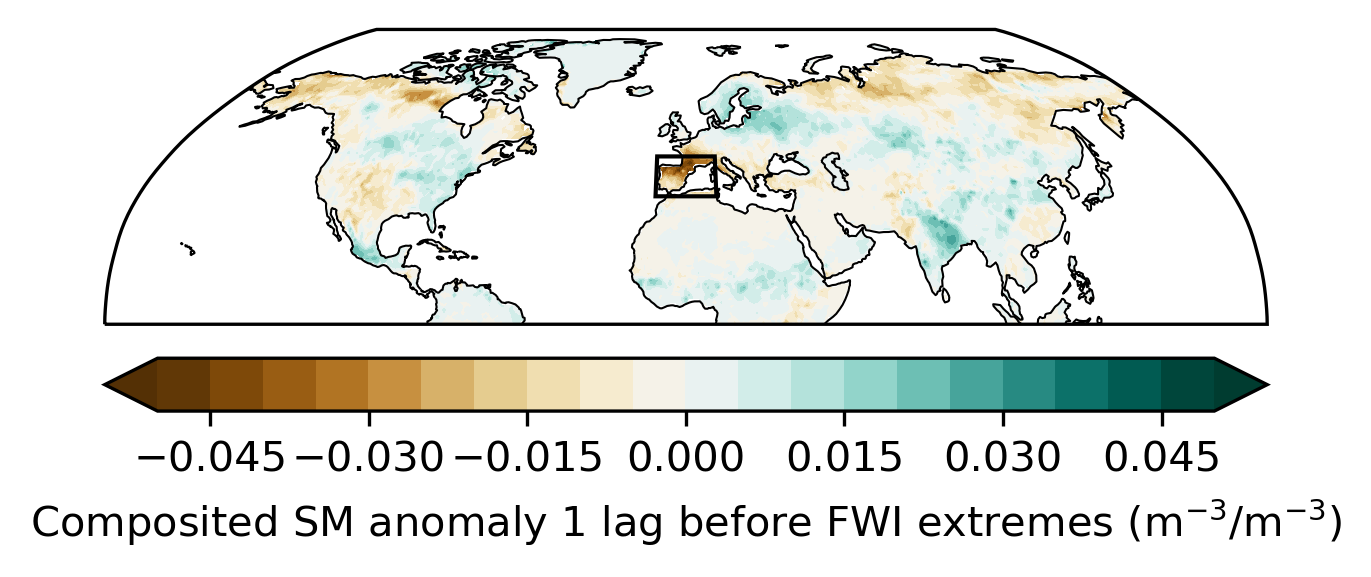

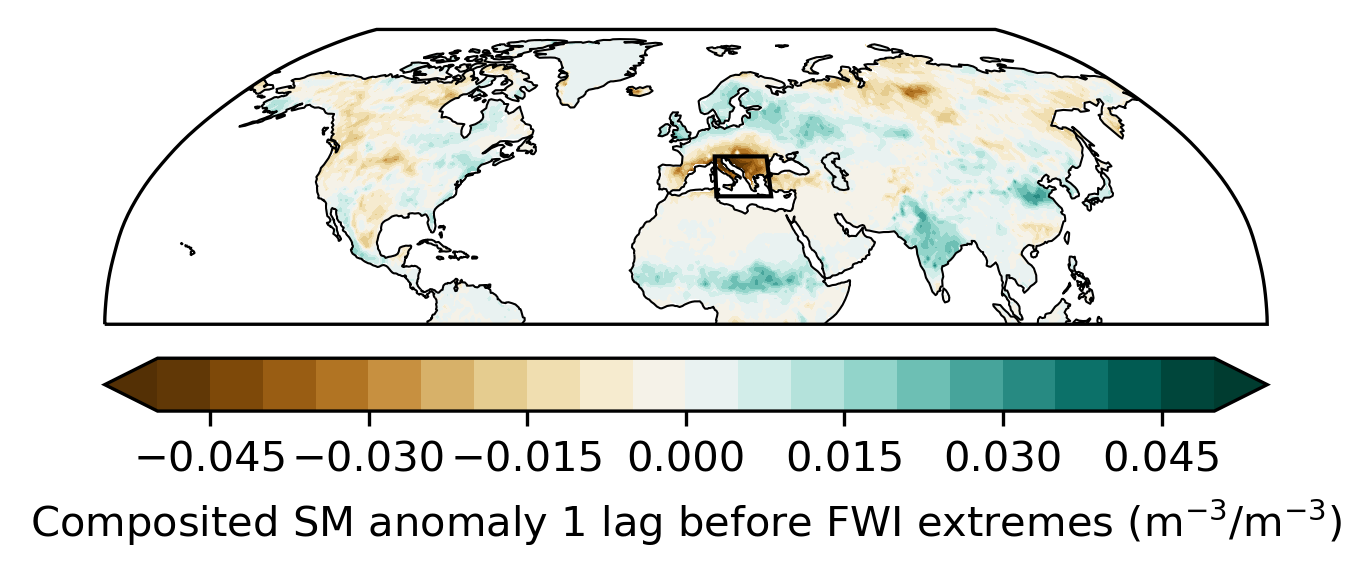

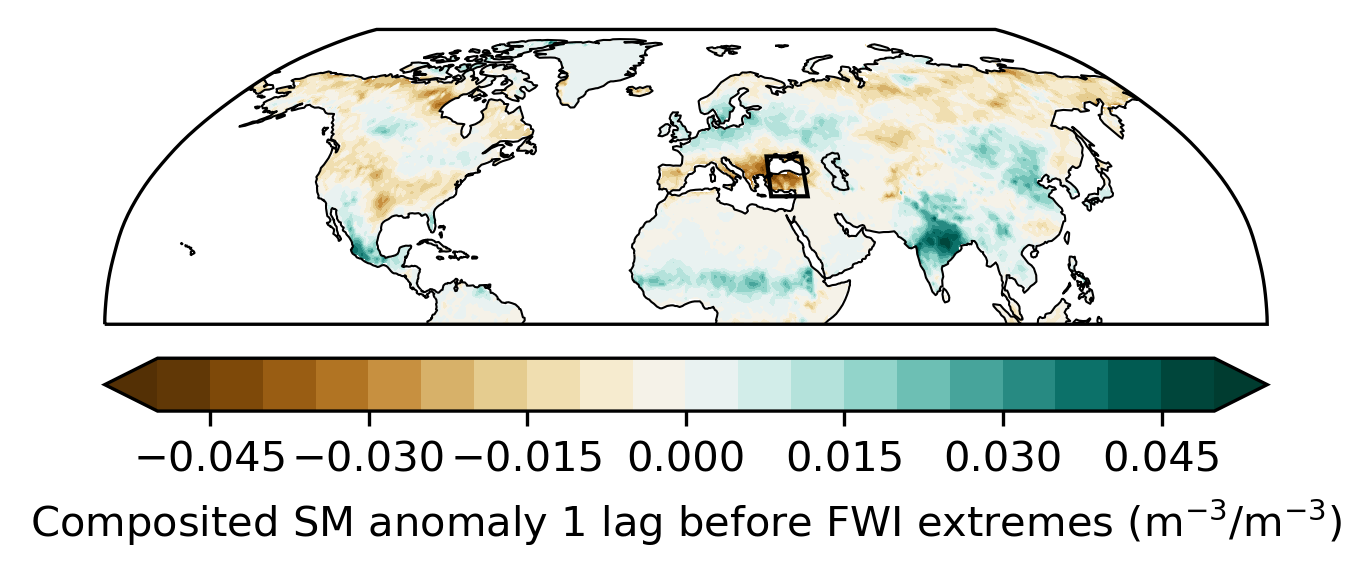

In [41]:

for k in cluster_sequence:

    temp_FWI = FWI_ano_region_clusters[k][29*31:]
    temp_FWI_thr = np.nanpercentile(temp_FWI,95)

    temp_JJA = np.nanmean(SM_JJA_std [np.where(temp_FWI>temp_FWI_thr)[0]-1] ,axis=0)
    temp_JJA[temp_JJA>10]=np.nan
    import matplotlib.patches as mpatches
    # 绘图
    fig, ax = plt.subplots(figsize=(5,3), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
    fig.patch.set_alpha(0)

    temp_cyclic, lon_cyclic = add_cyclic_point(temp_JJA, coord=LON_era5[0, :])
    lon2d, lat2d = np.meshgrid(lon_cyclic, LAT_era5[:, 0])


    levels = np.arange(-0.05,0.055,0.005)
    contour = ax.contourf(
        lon2d, lat2d, temp_cyclic,
        levels=levels,
        transform=ccrs.PlateCarree(),  
        cmap='BrBG',
        extend='both'
    )

    lon_min1 = lon1_min_clusters[k]
    lon_max1 = lon1_max_clusters[k]
    lat_min1 = lat1_min_clusters[k]
    lat_max1 = lat1_max_clusters[k]
    rect = mpatches.Rectangle(
        (lon_min1, lat_min1),                 # lower-left corner
        lon_max1 - lon_min1,                  # width
        lat_max1 - lat_min1,                  # height
        linewidth=1,
        edgecolor='black',
        facecolor='none',
        transform=ccrs.PlateCarree(),
        zorder=10
    )
    ax.add_patch(rect)

    ax.coastlines(linewidth=0.5)
    co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05)
    co.set_label(r'Composited SM anomaly 1 lag before FWI extremes (m$^{-3}$/m$^{-3}$)')
    ax.set_extent([-180,180,0,90], crs=ccrs.PlateCarree())
    # ax.set_title('ERA5')
    # ax.axis('off')
    plt.show()


# atmospheric driver

In [12]:
time_mask = (np.in1d(mon_era5_all,[6,7,8]))

year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]

##  Z500

In [26]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_Z500_1.x1._3daymean.nc') #current shape = (365, 180,360)

Z500 = np.squeeze(NCData.variables['var129'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()



In [27]:
time_mask = (np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,range(1979,2026)))
year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]


In [28]:
# Z500_region_clusters  = cluster_regional_mean(Z500)

Z500_JJA = Z500[(np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,range(1979,2026)))]
del Z500


In [29]:

X_std = copy.deepcopy(Z500_JJA)
for i_mon in set(mon_era5_all_JJA):
    mu  = np.nanmean(X_std[mon_era5_all_JJA==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all_JJA==i_mon] = X_std[mon_era5_all_JJA==i_mon] -mu

for i_year in set(year_era5_all_JJA):
    mu  = np.nanmean(X_std[year_era5_all_JJA==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all_JJA==i_year] = X_std[year_era5_all_JJA==i_year] -mu
    
Z500_JJA_std =copy.deepcopy( X_std)
del X_std

In [30]:
lon1_min_clusters = [10,28,-10]
lon1_max_clusters = [28,40,10]
lat1_min_clusters = [35,35,35]
lat1_max_clusters = [46,46,46]

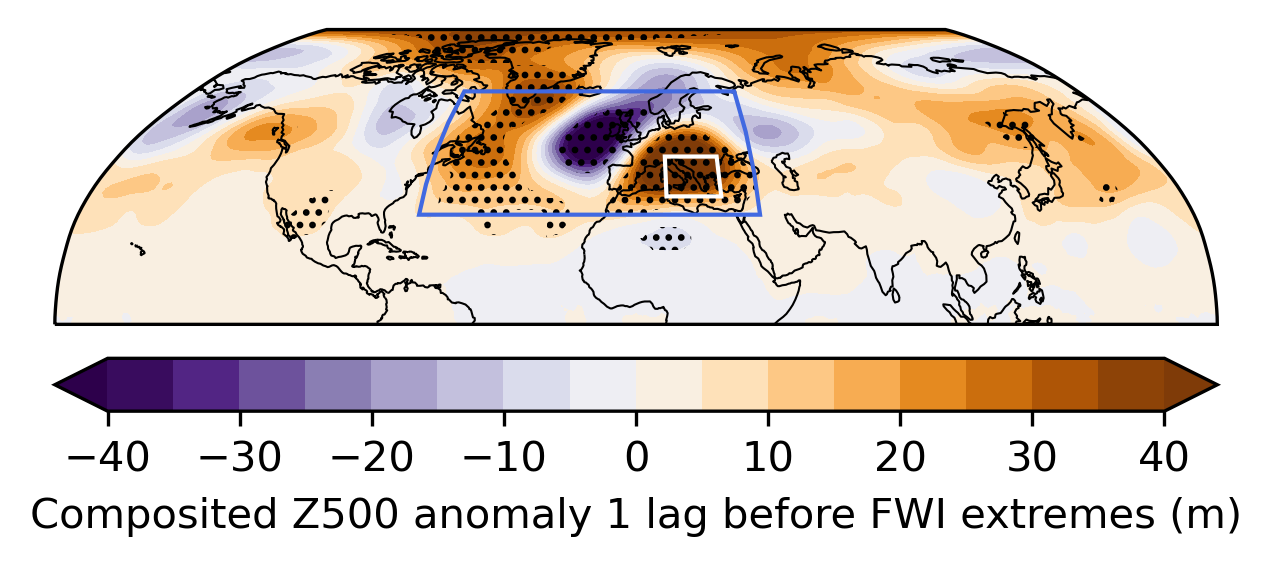

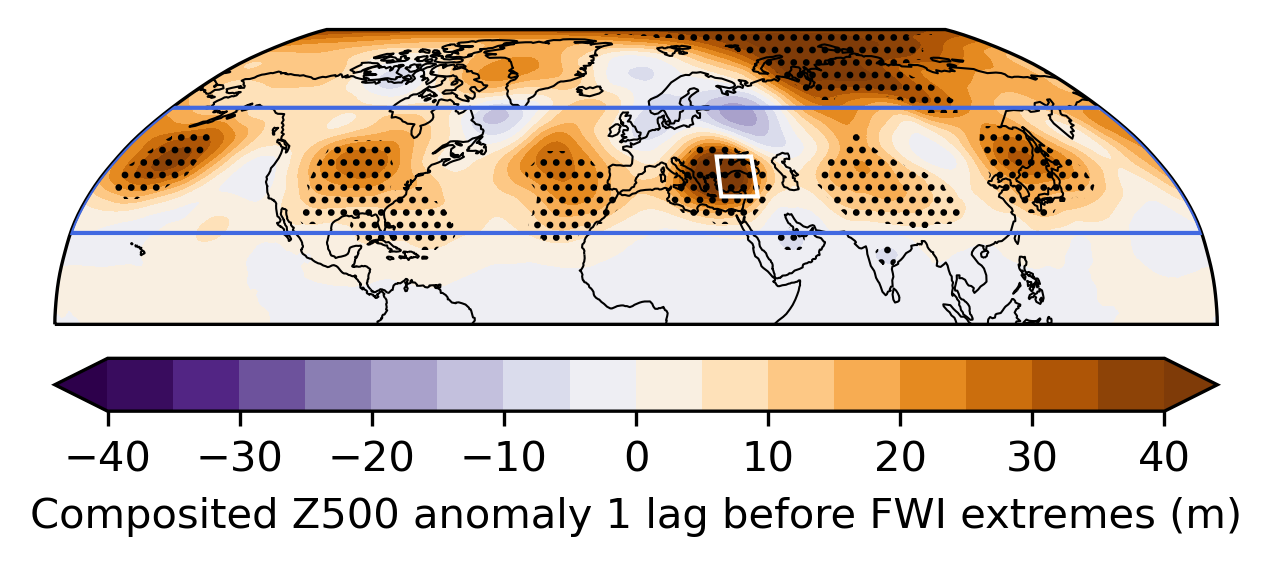

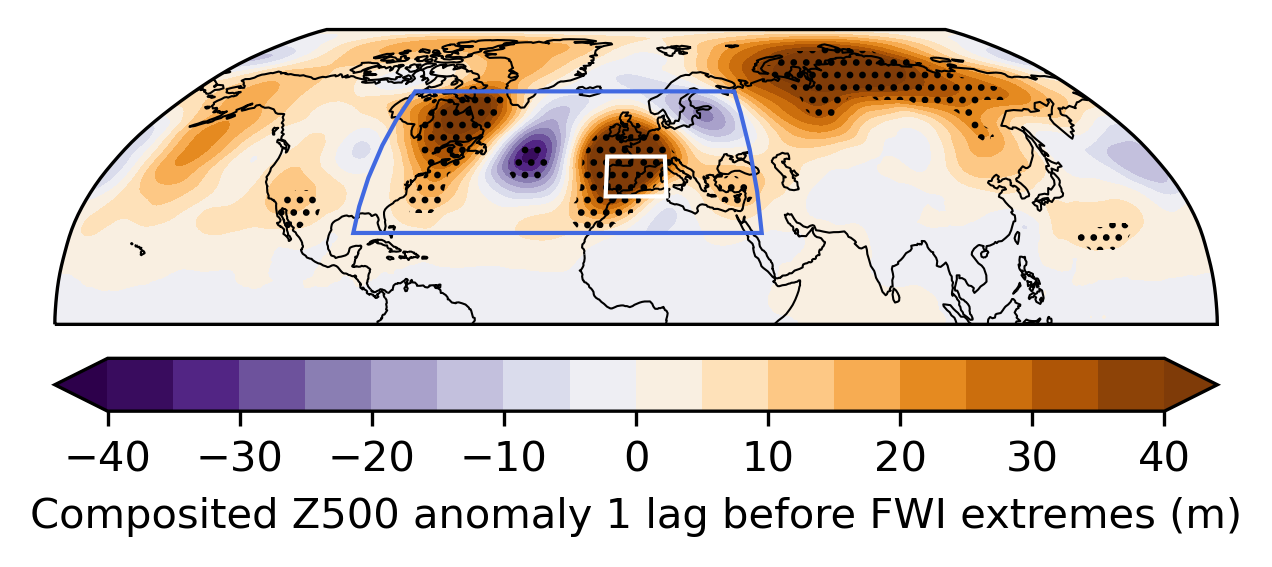

In [34]:
lon2_min_clusters = [-70,-180,-90]
lon2_max_clusters = [40,180,40]
lat2_min_clusters = [30,25,25]
lat2_max_clusters = [65,60,65]

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

alpha_fdr = 0.05  # FDR threshold (q-value)
lag = -1          # -1 = one timestep BEFORE the extreme, +1 = after

for k in range(n_clusters):

    temp_FWI = FWI_ano_region_clusters[k][31*29:]               # (time,)
    temp_FWI_thr = np.nanpercentile(temp_FWI, 95)

    mask_ext = temp_FWI > temp_FWI_thr                 # extreme at time t

    # -------------------------
    # Align lagged masks with Z500
    # -------------------------
    # For lag=-1: use Z[t] where extreme happens at t+1  (i.e., "one step before")
    if lag < 0:
        Z = Z500_JJA_std[:lag, :, :]                   # drop last |lag| times
        mask_ext_lag = mask_ext[-lag:]                 # drop first |lag| times
    elif lag > 0:
        Z = Z500_JJA_std[lag:, :, :]                   # drop first lag times
        mask_ext_lag = mask_ext[:-lag]                 # drop last lag times
    else:
        Z = Z500_JJA_std
        mask_ext_lag = mask_ext

    mask_non_lag = ~mask_ext_lag

    # Convert to meters
    Z_ext = Z[mask_ext_lag, :, :] / 9.8
    Z_non = Z[mask_non_lag, :, :] / 9.8

    # Composite anomaly (lagged): extreme-minus-nonextreme
    temp_JJA = np.nanmean(Z_ext, axis=0) - np.nanmean(Z/9.8, axis=0)

    # -------------------------
    # 1) Gridpoint significance (Welch t-test)
    # -------------------------
    tstat, pvals = ttest_ind(
        Z_ext, Z_non,
        axis=0,
        equal_var=False,
        nan_policy="omit"
    )

    # Sample-size filter
    n_ext = np.sum(np.isfinite(Z_ext), axis=0)
    n_non = np.sum(np.isfinite(Z_non), axis=0)
    valid = (n_ext >= 10) & (n_non >= 10) & np.isfinite(pvals)

    # -------------------------
    # 2) FDR across grid points
    # -------------------------
    sig_fdr = np.zeros_like(pvals, dtype=bool)
    qvals = np.full_like(pvals, np.nan, dtype=float)

    if np.any(valid):
        p_flat = pvals[valid].ravel()
        rej, q_flat, _, _ = multipletests(p_flat, alpha=alpha_fdr, method="fdr_bh")
        sig_fdr[valid] = rej
        qvals[valid] = q_flat

    effect_mask =np.abs(temp_JJA)>5
    sig_final = sig_fdr & effect_mask
    # -------------------------
    # 3) Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(5,3), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
    fig.patch.set_alpha(0)





    temp_cyclic, lon_cyclic = add_cyclic_point(temp_JJA, coord=LON_era5[0, :])
    lon2d, lat2d = np.meshgrid(lon_cyclic, LAT_era5[:, 0])


    levels = np.arange(-40, 45, 5)
    contour = ax.contourf(
        lon2d, lat2d, temp_cyclic,
        levels=levels,
        transform=ccrs.PlateCarree(),
        cmap='PuOr_r',
        extend='both'
    )

    ax.contourf(
        LON_era5, LAT_era5, sig_final.astype(int),
        levels=[0.5, 1.5],
        hatches=['....'],
        colors='none',
        transform=ccrs.PlateCarree()
    )

    lon_min1 = lon1_min_clusters[k]
    lon_max1 = lon1_max_clusters[k]
    lat_min1 = lat1_min_clusters[k]
    lat_max1 = lat1_max_clusters[k]
    rect1 = mpatches.Rectangle(
        (lon_min1, lat_min1),                 # lower-left corner
        lon_max1 - lon_min1,                  # width
        lat_max1 - lat_min1,                  # height
        linewidth=1,
        edgecolor='white',
        facecolor='none',
        transform=ccrs.PlateCarree(),
        zorder=10
    )
    ax.add_patch(rect1)
    
    lon_min2 = lon2_min_clusters[k]
    lon_max2 = lon2_max_clusters[k]
    lat_min2 = lat2_min_clusters[k]
    lat_max2 = lat2_max_clusters[k]
    
    rect2 = mpatches.Rectangle(
        (lon_min2, lat_min2),
        lon_max2 - lon_min2,
        lat_max2 - lat_min2,
        linewidth=1,
        edgecolor='royalblue',
        facecolor='none',
        transform=ccrs.PlateCarree(),
        zorder=10
    )
    ax.add_patch(rect2)


    ax.coastlines(linewidth=0.5)
    co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05)
    co.set_label(r'Composited Z500 anomaly 1 lag before FWI extremes (m)')
    ax.set_extent([-180, 180, 0, 90], crs=ccrs.PlateCarree())

    plt.show()

### cal Z500 index_fwi_95

In [68]:
lon2_min_clusters = [-70,-180,-90]
lon2_max_clusters = [40,180,40]
lat2_min_clusters = [30,25,25]
lat2_max_clusters = [65,60,65]


In [57]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_Z500_1.x1._3daymean.nc') #current shape = (365, 180,360)

Z500 = np.squeeze(NCData.variables['var129'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()


# X_std = copy.deepcopy(Z500)
# for i_mon in set(mon_era5_all):
#     mu  = np.nanmean(X_std[mon_era5_all==i_mon] , axis=0, keepdims=True)
#     X_std[mon_era5_all==i_mon] = X_std[mon_era5_all==i_mon] -mu

# for i_year in set(year_era5_all):
#     mu  = np.nanmean(X_std[year_era5_all==i_year] , axis=0, keepdims=True)
#     X_std[year_era5_all==i_year] = X_std[year_era5_all==i_year] -mu
    
# Z500_std =copy.deepcopy( X_std)
# del X_std
# # del Z500

In [ ]:

# Z500_JJA = Z500[np.in1d(mon_era5_all,[6,7,8])]
# del Z500

# X_std = copy.deepcopy(Z500_JJA)
# for i_mon in set(mon_era5_all_JJA):
#     mu  = np.nanmean(X_std[mon_era5_all_JJA==i_mon] , axis=0, keepdims=True)
#     X_std[mon_era5_all_JJA==i_mon] = X_std[mon_era5_all_JJA==i_mon] -mu

# for i_year in set(year_era5_all_JJA):
#     mu  = np.nanmean(X_std[year_era5_all_JJA==i_year] , axis=0, keepdims=True)
#     X_std[year_era5_all_JJA==i_year] = X_std[year_era5_all_JJA==i_year] -mu
    
# Z500_JJA_std =copy.deepcopy( X_std)
# del X_std

In [55]:
time_mask = (np.in1d(year_era5_all,range(1979,2026)))
year_era5_all_JJA1 = year_era5_all[time_mask ]
mon_era5_all_JJA1 = mon_era5_all[time_mask ]
day_era5_all_JJA1 = day_era5_all[time_mask ]

In [59]:
Z500_1 = Z500[np.in1d(year_era5_all,range(1979,2026))]
del Z500

In [60]:

X_std = copy.deepcopy(Z500_1)
for i_mon in set(mon_era5_all_JJA1):
    mu  = np.nanmean(X_std[mon_era5_all_JJA1==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all_JJA1==i_mon] = X_std[mon_era5_all_JJA1==i_mon] -mu

for i_year in set(year_era5_all_JJA1):
    mu  = np.nanmean(X_std[year_era5_all_JJA1==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all_JJA1==i_year] = X_std[year_era5_all_JJA1==i_year] -mu
    
Z500_std =copy.deepcopy( X_std)
del X_std

In [69]:


lag = -1          # -1 = one timestep BEFORE the extreme, +1 = after

Z500_region_clusters = []
for k in range(n_clusters):

    temp_FWI = FWI_ano_region_clusters[k] [31*29:]             # (time,)
    temp_FWI_thr = np.nanpercentile(temp_FWI, 95)

    mask_ext = temp_FWI > temp_FWI_thr                 # extreme at time t

    # -------------------------
    # Align lagged masks with Z500
    # -------------------------
    # For lag=-1: use Z[t] where extreme happens at t+1  (i.e., "one step before")
    if lag < 0:
        Z = Z500_JJA_std[:lag, :, :]                   # drop last |lag| times
        mask_ext_lag = mask_ext[-lag:]                 # drop first |lag| times
    elif lag > 0:
        Z = Z500_JJA_std[lag:, :, :]                   # drop first lag times
        mask_ext_lag = mask_ext[:-lag]                 # drop last lag times
    else:
        Z = Z500_JJA_std
        mask_ext_lag = mask_ext

    mask_non_lag = ~mask_ext_lag

    # Convert to meters
    Z_ext = Z[mask_ext_lag, :, :] / 9.8
    Z_non = Z[mask_non_lag, :, :] / 9.8

    # Composite anomaly (lagged): extreme-minus-nonextreme
    temp_JJA = np.nanmean(Z_ext, axis=0) - np.nanmean(Z/9.8, axis=0)


    lon_min2 = lon2_min_clusters[k]
    lon_max2 = lon2_max_clusters[k]
    lat_min2 = lat2_min_clusters[k]
    lat_max2 = lat2_max_clusters[k]
    

    mask_pattern = (LAT_era5<=lat_max2)&(LAT_era5>=lat_min2)&(LON_era5<=lon_max2)&(LON_era5>=lon_min2)
    ref_pattern = temp_JJA[mask_pattern]

    Z500_index = []
    for i in Z500_std:
        temp_pattern = i[mask_pattern]
        slope, intercept, r, p, stderr = linregress( ref_pattern , temp_pattern)
        Z500_index.append(r)
    Z500_region_clusters.append(np.array(Z500_index))
        


In [264]:
for k in range(n_clusters):
    np.save('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/'+cluster_names[k]+'_Z500_pattern_index_1979_2025_3d_95',Z500_region_clusters[k])

In [52]:
Z500_region_clusters = []
for k in range(n_clusters):
    Z500_region_clusters.append( np.load('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/'+cluster_names[k]+'_Z500_pattern_index_1979_2025_3d_95.npy',allow_pickle='True'))
n_clusters = 3

W-Med: slope = -0.000 /yr (95% CI [-0.001, 0.000])
C-Med: slope = -0.000 /yr (95% CI [-0.001, 0.001])
E-Med: slope = -0.000 /yr (95% CI [-0.001, 0.001])


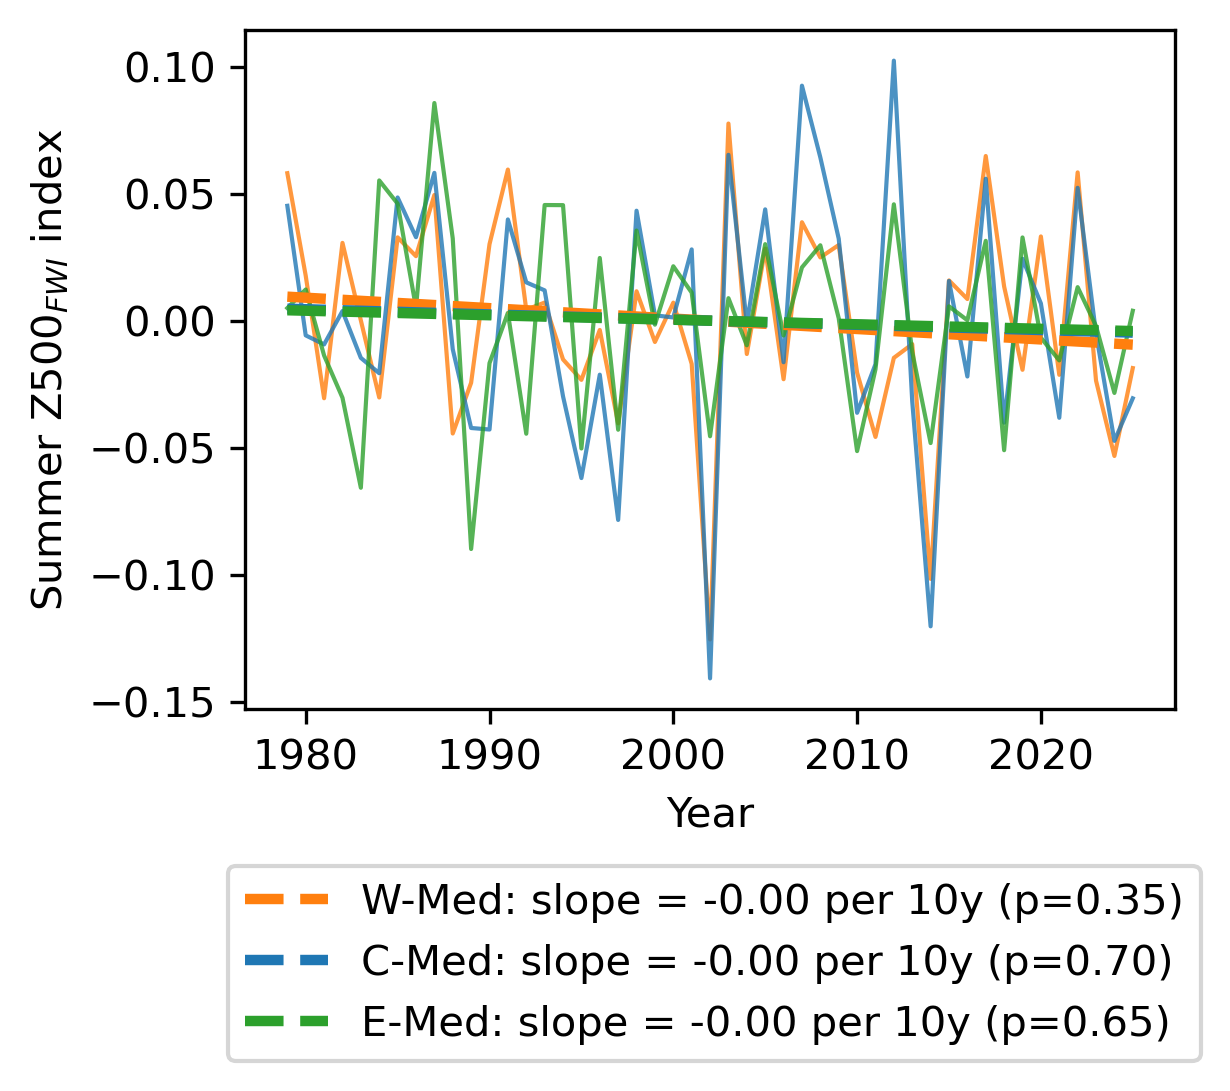

In [58]:




years = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}

for k in cluster_sequence:
    temp = Z500_region_clusters[k]
    temp = (temp - np.nanmean(temp))/(np.nanstd(temp))
    # temp = temp[np.in1d(mon_era5_all,[6,7,8])]

    # temp_yearmean = np.array([
    #     np.nanmean(temp[year_era5_all_JJA == y][temp_FWI[year_era5_all_JJA == y]>temp_FWI_thr] ) for y in years
    # ])
    temp_yearmean = np.array([
        np.nanmean(temp[year_era5_all_JJA1 == y] ) for y in years
    ])

    temp_yearmean = temp_yearmean 
   
    annual_means[k] = temp_yearmean

    ax.plot(
        years,
        temp_yearmean,
        color=cluster_colors[k],
        lw=1.,
        alpha=0.8,
        # label=cluster_names[k]
    )


for k in cluster_sequence:
    y = annual_means[k]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]

    if p<0.01:

        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10y (p<0.01)" 
        )
    else:

        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10y (p={p:.2f})" 
        )        

    print(
        f"{cluster_names[k]}: "
        f"slope = {slope:.3f} /yr "
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )

# for k in cluster_sequence:
#     y = annual_means[k]
#     mask = ~np.isnan(y)

#     lowess_fit = lowess(
#         y[mask],
#         years[mask],
#         frac=0.2,      # ~15-year smoothing
#         return_sorted=False
#     )

#     ax.plot(
#         years[mask],
#         lowess_fit,
#         color=cluster_colors[k],
#         lw=3,
#         alpha=0.35,
#         label = f"{cluster_names[k]}: " + f"LOESS" 
#     )
ax.set_xlabel('Year')
ax.set_ylabel('Summer Z500$_{FWI}$ index')
plt.legend(bbox_to_anchor=(1.05,-0.2))

